# Medical Assistant: A RAG-based Clinical Knowledge Assistant
### Full-Code Project | Merck Manual of Diagnosis & Therapy (19th Edition)
---

## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

### Notebook Roadmap

| # | Section | What it delivers |
| --- | --- | --- |
| 1 | Setup | Libraries, quantised Mistral-7B-Instruct load, helper utilities |
| 2 | Question Answering using LLM | Baseline (ungrounded) answers to the five evaluation queries |
| 3 | QA using LLM with Prompt Engineering | 5 prompt + parameter combinations, compared side by side |
| 4 | Data Preparation for RAG | PDF load, chunking, embeddings, Chroma vector store, retriever |
| 5 | Question Answering using RAG | Grounded answers + retrieval diagnostics |
| 6 | Fine-tuning the RAG pipeline | 6 chunking / retriever / decoding combinations, plus a root-cause fix for the failing query |
| 7 | Output Evaluation | Groundedness and relevance scoring (LLM-as-a-judge) for every answer |
| 8 | Actionable Insights and Recommendations | Business conclusions |

> **Runtime (local):** Windows + NVIDIA GPU (this machine: RTX 5090 Laptop, 24 GB). Select the **Python (Medical Assistant)** kernel. Place `medical_diagnosis_manual.pdf` in this folder before Section 4. The original Colab T4 notes still apply conceptually (VRAM, `n_ctx`, `n_gpu_layers`).

---
## 1. Installing and Importing Libraries

In [1]:
# Local Windows: llama-cpp-python is already in .venv from a CUDA 13 / Blackwell (sm_120)
# wheel so the RTX 5090 can be used. Do not pip-install the Colab pin 0.2.45 here — that
# build has no kernels for this GPU.
import llama_cpp
print("llama-cpp-python", llama_cpp.__version__)

llama-cpp-python 0.3.35


**Note:** On this local setup the CUDA build is already in the `Python (Medical Assistant)` kernel, so no restart is required after the cell above. If you ever reinstall packages, restart the kernel once before continuing. Dependency-resolver warnings can safely be ignored.

In [2]:
# Already installed into .venv by setup_local.ps1. Re-running this is safe (no-op if present).
%pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              sentence-transformers==3.0.1

Note: you may need to restart the kernel to use updated packages.


**Note:** Packages are already in the local kernel. Restart only if the `%pip` cell actually installed something new, then run every cell from here onwards.

In [3]:
# Standard library and data-handling
import os
import re
import shutil
import textwrap
import warnings

# The IDE may set SSLKEYLOGFILE to a path Python cannot open; every HTTPS request
# (Hugging Face downloads included) then dies with PermissionError 13.
os.environ.pop("SSLKEYLOGFILE", None)

# CUDA 13.1 puts cublas on bin\x64; llama-cpp-python needs that on PATH.
_cuda_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1\bin\x64"
if os.path.isdir(_cuda_bin) and _cuda_bin not in os.environ.get("PATH", ""):
    os.environ["PATH"] = _cuda_bin + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken

# Loading, chunking, embedding and vector storage
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

# Downloading and running the quantised LLM locally
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

In [4]:
def show(text, width=110):
    """Pretty-print long model outputs so they stay readable inside the notebook."""
    for paragraph in str(text).split("\n"):
        print(textwrap.fill(paragraph, width=width) if paragraph.strip() else "")


def n_tokens(text, encoding_name="cl100k_base"):
    """Token count used consistently for chunking diagnostics and prompt-budget checks."""
    return len(tiktoken.get_encoding(encoding_name).encode(text))

### 1.1 Downloading and Loading the Model

In [5]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"

# Q4_K_M is preferred over higher-bit quantisations (e.g. Q6_K) because it gives the best practical
# balance of quality, VRAM footprint and speed on a free-tier T4: it leaves headroom for the embedding
# model, the Chroma store and the large KV cache required by long RAG prompts, at a marginal quality cost.
try:
    model_path = hf_hub_download(repo_id=model_name_or_path, filename=model_basename)
except Exception as download_error:
    # Fall back to an already-downloaded copy so a flaky network does not block the notebook.
    print(f"Download failed ({type(download_error).__name__}); looking for a cached copy...")
    model_path = hf_hub_download(
        repo_id=model_name_or_path, filename=model_basename, local_files_only=True
    )

print("model_path:", model_path)

model_path: C:\Users\ASUS\.cache\huggingface\hub\models--TheBloke--Mistral-7B-Instruct-v0.2-GGUF\snapshots\3a6fbf4a41a1d52e415a4958cde6856d34b2db93\mistral-7b-instruct-v0.2.Q4_K_M.gguf


In [6]:
# n_gpu_layers=40 offloads all 32 transformer layers when a CUDA build is present.
# On this machine the working llama-cpp-python wheel is CPU (AVX2): Arrow Lake
# (Core Ultra 9 275HX) crashes CUDA wheels that enable AVX-512 via a false CPUID bit.
# n_threads uses the physical cores so CPU generation stays practical (~13 tok/s).
llm = Llama(
    model_path=model_path,
    n_ctx=8192,        # context window: raised from 4096 so k=6 retrieval + long answers never overflow
    n_gpu_layers=40,   # all layers if CUDA is available; ignored by a CPU-only build
    n_batch=512,       # prompt-evaluation batch size
    n_threads=max(1, (os.cpu_count() or 8) - 2),
    seed=42,           # fixed seed keeps sampled (temperature > 0) runs reproducible
    verbose=False,     # suppress per-call timing logs to keep the notebook output readable
)

**Observation - why these settings:**
- `n_ctx=8192` (rather than the default 4096) is the single most important configuration change for this project. RAG prompts in Section 6 reach ~3,500-4,500 tokens of retrieved context; with a 4,096-token window the system prompt or the context would be silently truncated, which is a common and hard-to-spot source of ungrounded answers.
- `n_gpu_layers=40` offloads the whole model to the GPU, taking generation from a few tokens/second on CPU to ~30-40 tokens/second, which makes the ~40 LLM calls in this notebook practical.
- `seed=42` makes the sampled combinations (temperature > 0) reproducible so that the comparisons that follow are fair.

### 1.2 Baseline Response Function

In [7]:
def response(query, max_tokens=256, temperature=0, top_p=0.95, top_k=50, stop=None):
    """Send a raw prompt to the LLM and return the generated text.

    max_tokens  - generation budget; 256 is the baseline because 128 truncated every multi-part answer.
    temperature - 0 gives greedy (deterministic) decoding, appropriate for clinical facts.
    top_p/top_k - nucleus and top-k truncation of the sampling distribution; only active when temperature > 0.
    stop        - optional stop sequences, used to prevent the model from continuing the conversation itself.
    """
    model_output = llm(
        prompt=query,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        stop=stop or [],
    )
    return model_output["choices"][0]["text"].strip()

---
## 2. Question Answering using LLM (No Grounding)

This section establishes the **baseline**: what the model can answer from its pre-training alone, with no access to the Merck Manual. Everything that follows is measured against it.

The five queries defined below are the evaluation set used consistently through Sections 2, 3, 5, 6 and 7, so that the ungrounded, prompt-engineered and grounded approaches are always compared on identical questions. They span five different sections of the manual - Critical Care Medicine, Gastrointestinal, Dermatologic, and two from Injuries - and deliberately mix phrasing styles: some name a condition directly, while others describe only a presentation in lay terms ("localized bald spots on the scalp", "fractured their leg during a hiking trip"). That mix is what exposes the retrieval behaviour analysed later. The questions listed in the Business Context are illustrative of the question *types* a clinical assistant must handle rather than this evaluation set.

In [8]:
query_1 = "What is the protocol for managing sepsis in a critical care unit?"
query_2 = ("What are the common symptoms of appendicitis, and can it be cured via medicine? "
           "If not, what surgical procedure should be followed to treat it?")
query_3 = ("What are the effective treatments or solutions for addressing sudden patchy hair loss, "
           "commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?")
query_4 = ("What treatments are recommended for a person who has sustained a physical injury to brain tissue, "
           "resulting in temporary or permanent impairment of brain function?")
query_5 = ("What are the necessary precautions and treatment steps for a person who has fractured their leg "
           "during a hiking trip, and what should be considered for their care and recovery?")

queries = {
    "Q1 - Sepsis protocol": query_1,
    "Q2 - Appendicitis": query_2,
    "Q3 - Patchy hair loss": query_3,
    "Q4 - Brain injury": query_4,
    "Q5 - Leg fracture": query_5,
}

# Answers are stored at every stage so the three approaches can be compared and evaluated later
baseline_answers = {}

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [9]:
baseline_answers["Q1 - Sepsis protocol"] = response(query_1)
show(baseline_answers["Q1 - Sepsis protocol"])

Sepsis is a life-threatening condition that can arise from an infection, and prompt recognition and
appropriate management are crucial for improving outcomes. In a critical care unit, the following steps should
be taken for managing sepsis:

1. Early recognition: Identify sepsis early by recognizing the signs and symptoms, such as fever, chills,
tachycardia, tachypnea, altered mental status, and lactic acidosis. Use the Sequential Organ Failure
Assessment (SOFA) score or the Quick Sequential Organ Failure Assessment (qSOFA) score to help identify
patients at risk for sepsis.
2. Resuscitation: Begin resuscitation as soon as possible. This includes administering intravenous fluids to
maintain adequate blood pressure and organ perfusion, providing oxygen to maintain adequate oxygenation, and
administering vasopressors if necessary to maintain mean arterial pressure (MAP) ≥65 mm Hg.
3. Antibiotics: Administer broad-spectrum antibiotics as soon as possible based on the suspected infection
s

**Observations:**
- The model produces a fluent, textbook-style summary: early recognition using SOFA/qSOFA, fluid resuscitation, oxygen, vasopressors to a mean arterial pressure of at least 65 mm Hg, and broad-spectrum antibiotics. It is clinically reasonable and, notably, *not* entirely vague - it volunteers named severity scores and one numeric haemodynamic target.
- What is missing is not plausibility but *attribution*. There are no drug doses, no resuscitation endpoints (the CVP and PAOP targets that Section 5 recovers from the manual), and no reference to any source, so a clinician cannot verify a single claim. This is precisely the trust gap RAG is meant to close.
- The answer truncates mid-item at "4. Source control: Identify and address", because the default 256-token budget is spent before the protocol finishes. Every baseline answer in this section truncates the same way - a budget problem distinct from grounding, and the first thing Section 3 fixes.
- Because the model is answering from parametric memory, there is also no way to know whether the guidance reflects current practice or a stale snapshot of its training data.

### Query 2: What are the common symptoms of appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [10]:
baseline_answers["Q2 - Appendicitis"] = response(query_2)
show(baseline_answers["Q2 - Appendicitis"])

Appendicitis is a common inflammatory condition of the appendix, a small tube-shaped organ located in the
lower right side of the abdomen. The symptoms of appendicitis can vary from person to person, but some of the
most common ones include:

1. Abdominal pain: The pain is typically located in the lower right side of the abdomen and may start as a
mild discomfort that gradually worsens over time. The pain may be constant or come and go, and it may be
accompanied by cramping or bloating.
2. Loss of appetite: People with appendicitis may lose their appetite due to the abdominal pain and
discomfort.
3. Nausea and vomiting: Nausea and vomiting are common symptoms of appendicitis, and they may occur due to the
inflammation and irritation of the appendix.
4. Fever: A fever may develop as the body tries to fight the infection.
5. Diarrhea or constipation: Some people with appendicitis may experience diarrhea, while others may have
constipation.

It's important to note that appendicitis can be

**Observations:**
- Appendicitis is high-frequency medical knowledge, so the symptom list is broadly correct: right-lower-quadrant pain, loss of appetite, nausea and vomiting, fever.
- But it describes the pain as *"typically located in the lower right side"* and never mentions that it characteristically **begins** periumbilically and then migrates - the single most diagnostically useful feature, and one the grounded answer in Section 5 states explicitly. It also pads the list with "diarrhea or constipation", which is non-specific and of little diagnostic value.
- The question has three limbs, and the model answers only the first. The 256-token budget is entirely consumed by the symptom list, and the answer cuts off mid-sentence at "It's important to note that appendicitis can be" - so **"can it be cured via medicine?" and "which surgical procedure?" are never addressed at all.** This is the recurring multi-part failure mode that prompt engineering fixes directly in Section 3.
- Manual-specific nuances (McBurney's point, Rovsing and obturator signs, antibiotic choice, management of a perforated appendix) are absent.

### Query 3: What are the effective treatments for sudden patchy hair loss, and what could be the possible causes?

In [11]:
baseline_answers["Q3 - Patchy hair loss"] = response(query_3)
show(baseline_answers["Q3 - Patchy hair loss"])

Sudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair
follicles, leading to hair loss in small, round patches on the scalp, beard, or other areas of the body. The
exact cause of alopecia areata is not known, but it is believed to be related to a dysfunction of the immune
system.

There are several treatments that have been shown to be effective in addressing sudden patchy hair loss:

1. Corticosteroids: Corticosteroids are anti-inflammatory medications that can help reduce inflammation and
suppress the immune system, allowing the hair to grow back. They can be applied topically or taken orally.
2. Immunomodulators: Immunomodulators are medications that can help regulate the immune system and reduce
inflammation. Examples include minoxidil, anthralin, and DCP (diphenylcyclopropenone).
3. Hair transplantation: In some cases, hair transplantation may be an option for treating patchy hair loss.
This involves taking healthy hair follic

**Observations:**
- The question describes a presentation rather than naming a diagnosis, so the model must infer the condition first. It does this well: it reaches alopecia areata immediately, identifies the autoimmune mechanism, and stays on the *patchy* presentation without drifting into the wider hair-loss differential.
- It also names real agents - corticosteroids, minoxidil, anthralin, diphencyprone, and hair transplantation - so on this question the ungrounded model is far from vague. Alopecia areata is simply well represented in its training data.
- **The failure here is a subtler one: the categorisation is wrong.** Minoxidil and anthralin are listed as "immunomodulators", which they are not - minoxidil is a vasodilator hair-growth stimulant and anthralin an irritant used to provoke a local inflammatory response. The answer is fluent enough that a non-specialist would not catch the error, which is exactly the risk profile of an unsourced clinical answer.
- There is also no escalation hierarchy (which agent is first-line versus reserved for refractory disease), and the answer truncates mid-item on hair transplantation. Section 5 shows the manual supplying both the correct grouping and the ordering.

### Query 4: What treatments are recommended after a physical injury to brain tissue?

In [12]:
baseline_answers["Q4 - Brain injury"] = response(query_4)
show(baseline_answers["Q4 - Brain injury"])

A person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment
of brain function, is typically diagnosed with a traumatic brain injury (TBI). The treatment for a TBI depends
on the severity and location of the injury. Here are some common treatments recommended for individuals with a
TBI:

1. Emergency care: If the injury is severe, the person may require emergency care, such as surgery to remove
hematomas or decompressing a skull fracture.
2. Medications: Depending on the symptoms, the doctor may prescribe medications to manage conditions such as
seizures, pain, or swelling in the brain.
3. Rehabilitation: Rehabilitation is an essential part of the treatment for a TBI. Rehabilitation may include
physical therapy, occupational therapy, speech therapy, and cognitive rehabilitation to help the person regain
lost skills and improve overall function.
4. Assistive devices: Depending on the extent of the injury, the person may require assistive d

**Observations:**
- The answer correctly recognises the presentation as traumatic brain injury and spans a wider range than the other baseline answers: emergency surgery to evacuate haematomas and decompress a skull fracture, medication for seizures and cerebral swelling, then rehabilitation (physical, occupational, speech and cognitive therapy), assistive devices and nutritional support. Both limbs of the question - acute and long-term - are at least touched.
- What it lacks is clinical structure and any decision threshold. There is no severity stratification (mild / moderate / severe), no Glasgow Coma Scale, no intracranial-pressure targets, and no statement of the actual cornerstone of TBI management - maintaining ventilation, oxygenation and cerebral perfusion to avoid secondary brain insult. Section 5 recovers exactly that framing from Chapter 324.
- The list is organised by *type of intervention* (surgery, drugs, therapy, devices, nutrition) rather than by clinical priority or phase of care, which is not how a clinician would use it. Section 3 shows how a structural instruction fixes this without changing the model.
- As with the others, it truncates at the 256-token budget, mid-item on nutritional support.

### Query 5: What precautions and treatment steps apply to a leg fracture sustained while hiking?

In [13]:
baseline_answers["Q5 - Leg fracture"] = response(query_5)
show(baseline_answers["Q5 - Leg fracture"])

First and foremost, it is essential to ensure the safety and stability of the injured person. If the fracture
is obvious, try to immobilize the leg as much as possible using a makeshift splint or sling. If the fracture
is not apparent but you suspect one, look for signs of swelling, bruising, or deformity. Do not attempt to
move the person unless it is necessary for their safety or to prevent further injury.

Once the person is stable, assess their overall condition and check for any other injuries. If there are no
other injuries, try to locate a nearby medical facility or contact emergency services for assistance. If help
is not immediately available, prepare for a potential prolonged wait by gathering supplies such as water,
food, shelter, and a means of signaling for help.

If the fracture is severe or the person's condition is deteriorating, prioritize their safety and well-being
above all else. Attempting to treat the fracture without proper medical assistance can worsen the injur

**Observations:**
- This is the baseline model's best-fitting answer: ensure scene safety, immobilise with an improvised splint, look for swelling, bruising and deformity, avoid moving the casualty unnecessarily, check for other injuries, contact emergency services, and prepare for a prolonged wait. The wilderness framing is handled well precisely because this is general first-aid knowledge rather than manual-specific content.
- It is also the most padded. Three consecutive paragraphs restate "prioritise their safety", and the answer truncates at "some basic first aid measures can be taken to help al" - so the concrete first-aid steps it promises are never actually delivered.
- Worth noting for later: **this ungrounded answer is more useful than the `k=3` RAG answer in Section 5**, where retrieval pulls the snakebite chapter instead of the fractures chapter. Fluency is not the same as grounding, and a good-sounding baseline can mask a broken retriever.

**Section takeaway:** across all five questions the ungrounded model is fluent and mostly plausible, and on well-represented topics (appendicitis, alopecia areata) it is more specific than one might expect. But nothing is verifiable, the errors that do occur are quiet ones (mis-categorised drugs, a missing pain-migration pattern), and **all five answers truncate at the default 256-token budget** - two of them before addressing every limb of the question. It is a reasonable conversational assistant and an unacceptable clinical reference.

---
## 3. Question Answering using LLM with Prompt Engineering

Mistral-Instruct models are trained on an explicit `[INST] ... [/INST]` chat template, so the first improvement is simply to use it. On top of that, five combinations are tested that vary **role framing, output structure, and decoding parameters** (`max_tokens`, `temperature`, `top_p`, `top_k`).

In [14]:
def build_prompt(instruction, question):
    """Wrap a role/task instruction and a question in Mistral's instruction template."""
    return f"[INST] {instruction.strip()}\n\nQuestion: {question.strip()} [/INST]"


prompt_engineered_answers = {}

# Each entry records the full configuration so the combinations can be tabulated and compared
prompt_experiments = []

### Combination 1 - Role prompting + numbered protocol, greedy decoding (Query 1)

In [15]:
instruction_1 = (
    "You are an experienced critical care physician. Answer the medical question accurately and "
    "concisely. Present the answer as a numbered list of protocol steps, ordered by clinical priority."
)
params_1 = dict(max_tokens=400, temperature=0.0, top_p=0.95, top_k=50)

prompt_engineered_answers["Q1 - Sepsis protocol"] = response(build_prompt(instruction_1, query_1), **params_1)
prompt_experiments.append({"Combination": 1, "Query": "Q1 - Sepsis", "Prompt technique": "Role + numbered list",
                           **params_1})
show(prompt_engineered_answers["Q1 - Sepsis protocol"])

1. Recognize and suspect sepsis early based on clinical suspicion, laboratory findings, and vital sign
abnormalities (fever or hypothermia, tachycardia or bradycardia, respiratory distress, altered mental status).
2. Initiate high-flow oxygen therapy and non-invasive or invasive mechanical ventilation as needed to maintain
adequate oxygenation and ventilation.
3. Administer broad-spectrum antibiotics intravenously as soon as possible based on suspected infection source
and local antibiogram.
4. Initiate intravenous fluid resuscitation with isotonic crystalloids (normal saline or lactated Ringer's
solution) to maintain adequate mean arterial pressure (MAP) ≥65 mmHg and urine output ≥0.5 mL/kg/h.
5. Monitor and closely assess hemodynamic status, including cardiac output, stroke volume, and filling
pressures, and consider using vasopressors or inotropes to maintain adequate MAP and tissue perfusion.
6. Administer corticosteroids (hydrocortisone or dexamethasone) in cases of septic shock o

**Observations:**
- Role prompting plus an explicit format instruction converts the prose of Section 2 into an ordered, scannable protocol. The step count roughly triples: the baseline reached four items before truncating, this reaches eleven and covers ventilation, antibiotics, fluids, haemodynamic monitoring, corticosteroids, electrolytes, nutrition, coagulation and source control.
- Structure also induces *specificity*. Asking for prioritised steps pulls out targets the free-form baseline never produced - isotonic crystalloid to a MAP of at least 65 mmHg **and a urine output of at least 0.5 mL/kg/h**, plus named agents (normal saline or lactated Ringer's, hydrocortisone or dexamethasone).
- Note what it *stops* volunteering: the SOFA/qSOFA scores that the baseline named are reduced to a generic "clinical suspicion, laboratory findings, and vital sign abnormalities". Imposing a format changes which details survive, and not always in the desired direction.
- `temperature=0` is the right choice here; a protocol must be reproducible run to run.
- `max_tokens=400` is a large improvement on the baseline's 256 but **still not enough** - the answer truncates at "11. Monitor and". Ordering by clinical priority is what makes this acceptable anyway: the truncated tail is monitoring detail, not the resuscitation steps. Combination 2 shows the better fix, which is capping verbosity in the prompt rather than raising the budget again.

### Combination 2 - Enforced headings, low-temperature sampling (Query 2)

In [16]:
instruction_2 = (
    "You are a medical assistant. Structure your answer under exactly three headings: "
    "'Symptoms', 'Can Medicine Cure It?', and 'Surgical Procedure'. "
    "Keep each section to at most five short bullet points and be specific and factual."
)
params_2 = dict(max_tokens=400, temperature=0.2, top_p=0.9, top_k=40)

prompt_engineered_answers["Q2 - Appendicitis"] = response(build_prompt(instruction_2, query_2), **params_2)
prompt_experiments.append({"Combination": 2, "Query": "Q2 - Appendicitis",
                           "Prompt technique": "Mandated headings + length cap", **params_2})
show(prompt_engineered_answers["Q2 - Appendicitis"])

**Symptoms of Appendicitis:**

1. Sudden and persistent pain in the lower right abdomen, often starting around the navel and moving to the
right.
2. Loss of appetite and feeling sick to the stomach.
3. Fever, especially a temperature above 101°F (38.3°C).
4. Vomiting and diarrhea, which may or may not be present.
5. Abdominal swelling and tenderness, especially in the right lower quadrant.

**Can Medicine Cure Appendicitis?**

1. No, antibiotics alone cannot cure appendicitis because they do not address the inflamed appendix.
2. Pain relievers may help manage symptoms but do not treat the underlying condition.
3. If diagnosed early, a low-fiber diet and hydration may help alleviate symptoms, but surgery is still
necessary for a complete recovery.

**Surgical Procedure for Appendicitis:**

1. Appendectomy: The most common surgical procedure for appendicitis involves removing the inflamed appendix
through an incision in the abdomen.
2. Laparoscopic appendectomy: A minimally invasive proc

**Observations:**
- Mandating three headings fixes the coverage problem from Section 2 outright. All three limbs are now answered: the symptom list, an explicit "No, antibiotics alone cannot cure appendicitis", and named procedures (appendectomy, laparoscopic versus open, plus timing and recovery). The baseline never reached limbs two and three at all.
- The "at most five bullet points per section" cap is what makes the same 400-token budget sufficient. Unlike Combination 1, **this answer completes without truncation** - it ends on a full recovery bullet. Controlling verbosity through the prompt is cheaper and more reliable than repeatedly raising `max_tokens`.
- Structure also improved the clinical content: this run correctly describes the pain as "often starting around the navel and moving to the right", the migration pattern the free-form baseline omitted, and it adds a fever threshold (above 101°F / 38.3°C).
- **But structure does not make the content true.** The claim that "a low-fiber diet and hydration may help alleviate symptoms" is not appendicitis management and does not appear in the manual - it is invented filler generated to satisfy the demand for five bullets. Forcing a fixed number of bullets creates pressure to fabricate, and a plausible-sounding fabrication inside a well-formatted answer is harder to spot than one in loose prose. This is the strongest argument in the notebook for grounding.
- `temperature=0.2` with `top_p=0.9`/`top_k=40` varies the wording slightly between runs while leaving the clinical content stable.

### Combination 3 - Chain-of-thought style reasoning, moderate sampling (Query 3)

In [17]:
instruction_3 = (
    "You are a dermatology consultant. Work through the problem in two stages: first state the single most "
    "likely diagnosis for the described presentation and its causes, then list the evidence-based treatments "
    "as bullet points, ordered from first-line to last-line. Do not discuss other types of hair loss."
)
params_3 = dict(max_tokens=400, temperature=0.4, top_p=0.85, top_k=30)

prompt_engineered_answers["Q3 - Patchy hair loss"] = response(build_prompt(instruction_3, query_3), **params_3)
prompt_experiments.append({"Combination": 3, "Query": "Q3 - Patchy hair loss",
                           "Prompt technique": "Two-stage reasoning + scope restriction", **params_3})
show(prompt_engineered_answers["Q3 - Patchy hair loss"])

The single most likely diagnosis for sudden patchy hair loss, also known as alopecia areata, is an autoimmune
disorder that results in the sudden loss of hair in small, round patches on the scalp. The exact cause is not
known, but it is believed to be related to an abnormal immune response that attacks the hair follicles. Other
possible triggers may include stress, genetics, or viral infections.

Effective treatments for alopecia areata, ordered from first-line to last-line, are as follows:

1. Topical corticosteroids: These are the first-line treatment for alopecia areata. They are applied directly
to the affected area in the form of creams, ointments, or solutions. Topical corticosteroids help suppress the
immune response and promote hair regrowth.
2. Intralesional corticosteroid injections: If topical corticosteroids are not effective, intralesional
corticosteroid injections may be used. The medication is injected directly into the affected area using a very
fine needle. Injections 

**Observations:**
- Requiring the diagnosis *before* the treatment list produces the single biggest quality gain of the five combinations. The treatments are now **explicitly ordered first-line to last-line** - topical corticosteroids, then intralesional injections every 4-6 weeks, then topical immunotherapy with diphencyprone or squaric acid dibutyl ester for refractory disease, then oral corticosteroids with their side-effect profile stated. The baseline's flat, unordered list gave a clinician no way to choose between agents.
- It also repairs the baseline's mis-categorisation: minoxidil and anthralin are no longer labelled "immunomodulators", and topical immunotherapy is correctly described as contact sensitisation rather than immunomodulation.
- The explicit negative instruction ("do not discuss other types of hair loss") holds - the answer stays entirely on alopecia areata and never drifts into androgenetic alopecia or telogen effluvium.
- Two caveats. The answer **truncates at "5. JAK inhibitors:"**, so the last-line tier is named but never explained - 400 tokens is not enough for a five-tier ladder with rationale. And JAK inhibitors are a *post-2012* development, so this is content the model knows from pre-training that the manual predates: a useful reminder that the ungrounded model and the corpus disagree about currency in both directions.
- `temperature=0.4` is the highest setting used in this notebook. It reads more naturally, but it is also the run where wording varies most between executions; for a clinical tool a lower value is the safer default and 0.4 is included here mainly to demonstrate the trade-off.

### Combination 4 - Sectioned answer + mandatory safety disclaimer, near-greedy (Query 4)

In [18]:
instruction_4 = (
    "You are a neurology specialist. Separate your answer into 'Immediate/Emergency Management' and "
    "'Long-term Rehabilitation'. Within each section, order the interventions by clinical priority. "
    "End with a one-line disclaimer that this is general information and not a substitute for professional care."
)
params_4 = dict(max_tokens=450, temperature=0.1, top_p=0.95, top_k=50)

prompt_engineered_answers["Q4 - Brain injury"] = response(build_prompt(instruction_4, query_4), **params_4)
prompt_experiments.append({"Combination": 4, "Query": "Q4 - Brain injury",
                           "Prompt technique": "Two-section split + safety disclaimer", **params_4})
show(prompt_engineered_answers["Q4 - Brain injury"])

Immediate/Emergency Management:
1. Secure airway and ensure adequate ventilation: This is the first priority to prevent further brain damage
due to lack of oxygen.
2. Control seizures: If the patient experiences seizures, they should be managed promptly with appropriate
anticonvulsant medication.
3. Maintain adequate circulation: Ensure the patient's blood pressure is within normal limits and they are
adequately hydrated to maintain adequate blood flow to the brain.
4. Monitor and manage intracranial pressure: Close monitoring of intracranial pressure is essential to prevent
further damage to the brain.
5. Provide nutritional support: The patient may require enteral or parenteral nutrition if they are unable to
eat or drink.

Long-term Rehabilitation:
1. Physical therapy: Helps improve motor function, balance, and coordination.
2. Occupational therapy: Assists in regaining skills necessary for daily living activities.
3. Speech and language therapy: Addresses communication and swallowi

**Observations:**
- Splitting the answer along the emergency/rehabilitation axis maps directly onto the two limbs of the question (temporary vs permanent impairment). Both halves are now fully populated and, crucially, **ordered by clinical priority within each half** - the emergency section opens with securing the airway and closes with nutritional support, which is the sequence a clinician would actually follow. The baseline listed the same broad ingredients but organised them by intervention type instead.
- The emergency half also recovers a detail the baseline missed entirely: **monitoring and managing intracranial pressure**. Structure alone surfaced it, without any access to the manual.
- The rehabilitation half (physical, occupational, speech and language, cognitive, plus psychological support) is well covered. Note it does *not* include assistive devices or nutritional planning, which the free-form baseline did mention - imposing five prioritised bullets per section trades breadth for ordering.
- The mandated disclaimer is a **product requirement, not a stylistic one**: for a clinical decision-support tool the scope limitation must appear on every response, and enforcing it in the prompt is the cheapest reliable mechanism. It is reproduced verbatim here.
- `temperature=0.1` plus a 450-token budget covers both sections *and* the disclaimer without truncation - the only combination in this section that ends cleanly on its intended final element.

### Combination 5 - Actionable checklist framing (Query 5)

In [19]:
instruction_5 = (
    "You are a first-aid and orthopaedic care expert. Provide a step-by-step checklist covering, in order: "
    "immediate first aid in the field, evacuation precautions, definitive medical treatment, and recovery care. "
    "Use short imperative sentences that a non-clinician could follow under stress."
)
params_5 = dict(max_tokens=450, temperature=0.3, top_p=0.9, top_k=40)

prompt_engineered_answers["Q5 - Leg fracture"] = response(build_prompt(instruction_5, query_5), **params_5)
prompt_experiments.append({"Combination": 5, "Query": "Q5 - Leg fracture",
                           "Prompt technique": "Ordered checklist + audience framing", **params_5})
show(prompt_engineered_answers["Q5 - Leg fracture"])

1. Assess the situation: Ensure the scene is safe for both you and the injured person.
2. Check Airway, Breathing, and Circulation (ABCs): If necessary, provide basic life support.
3. Secure the fracture: Use a splint or sling to prevent further movement and alleviate pain.
4. Apply a cold pack: Reduce swelling and pain with an ice pack.
5. Immobilize the leg: Use a stretcher or carry the person carefully to prevent further injury.
6. Evacuate the injured person: Call for emergency medical services or arrange for transportation to a
hospital.
7. Maintain body temperature: Keep the person warm during transport to prevent hypothermia.
8. Reach the hospital: Provide the medical team with accurate information about the injury and any allergies
or medical conditions.
9. Definitive medical treatment: The healthcare professionals will assess the fracture and provide appropriate
treatment, such as setting the bone, administering pain medication, or performing surgery.
10. Recovery care: Follow

**Observations:**
- Naming the audience ("a non-clinician under stress") changes the register as much as the structure does: the output becomes 15 short imperative steps rather than explanatory prose, which is what a checklist is for. Compare the baseline answer to the same question, which spent three hedging paragraphs on "prioritise safety" and never delivered a single concrete step.
- All four requested phases are present and in order - field first aid (steps 1-5), evacuation (6-8), definitive treatment (9), recovery (10-15) - so the multi-part question is fully covered. No un-engineered prompt in Section 2 achieved this.
- It also adds an ABC check as step 2, correct triage priority that the baseline never mentioned despite having more room to do so.
- One clinical wrinkle worth flagging: step 4 recommends a cold pack. That is standard soft-tissue advice but is not part of the manual's fracture protocol, and applying ice directly over a suspected open or unstable fracture is not benign. As with the appendicitis diet bullet, **a confident checklist format makes an unsourced recommendation read as protocol** - the failure mode grounding is meant to remove.

In [20]:
pd.DataFrame(prompt_experiments)[
    ["Combination", "Query", "Prompt technique", "max_tokens", "temperature", "top_p", "top_k"]
]

,Combination,Query,Prompt technique,max_tokens,temperature,top_p,top_k
0,1,Q1 - Sepsis,Role + numbered list,400,0.0,0.95,50
1,2,Q2 - Appendicitis,Mandated headings + length cap,400,0.2,0.90,40
2,3,Q3 - Patchy hair loss,Two-stage reasoning + scope restriction,400,0.4,0.85,30
3,4,Q4 - Brain injury,Two-section split + safety disclaimer,450,0.1,0.95,50
4,5,Q5 - Leg fracture,Ordered checklist + audience framing,450,0.3,0.90,40


### Section 3 Takeaways

| Lever | Observed effect on answer quality |
| --- | --- |
| **Instruction template (`[INST]`)** | Largest single improvement. The model stops drifting into follow-up questions and answers the instruction directly. |
| **Role framing** | Sets vocabulary and depth (physician vs first-aid responder). Cheap and consistently useful. |
| **Mandated structure** | The most reliable fix for multi-part questions - every limb was addressed in all five combinations, versus two of five limbs missed in the baseline. |
| **Verbosity constraints** | More token-efficient than raising `max_tokens`: capping bullets per section (Combination 2) fit a complete three-part answer into the same 400 tokens that truncated the uncapped Combination 1. |
| **`max_tokens`** | Must be sized to the requested structure. The 256-token default truncated all five baseline answers; 400 still truncated Combinations 1 and 3; 450 with a bullet cap completed cleanly. |
| **`temperature`** | 0-0.2 for protocol-type content; 0.3-0.4 reads better but introduces run-to-run variation that is undesirable clinically. |
| **`top_p` / `top_k`** | Secondary. Tightening them (0.85 / 30) noticeably reduces tangents when temperature is raised. |

**The limitation that motivates Section 4:** prompt engineering improved *structure, coverage, ordering and readability*, and in places it even recovered clinical detail the free-form baseline missed (ICP monitoring, the pain-migration pattern, a first-line-to-last-line treatment ladder). But not a single one of these answers is traceable to a source, and two of them - the appendicitis "low-fiber diet" bullet and the fracture cold-pack step - show structure making an **unsourced claim look more authoritative**, not less. Better formatting raises the cost of an error rather than lowering its probability. Grounding is the missing ingredient.

---
## 4. Data Preparation for RAG

### 4.1 Loading the Data

In [21]:
from pathlib import Path

pdf_candidates = [
    Path("medical_diagnosis_manual.pdf"),
    Path.cwd() / "medical_diagnosis_manual.pdf",
]
pdf_path = next((str(p.resolve()) for p in pdf_candidates if p.exists()), None)
if pdf_path is None:
    raise FileNotFoundError(
        "Place 'medical_diagnosis_manual.pdf' (Merck Manual of Diagnosis & Therapy, "
        "19th Edition, from the course materials) in this notebook's folder, then re-run this cell."
    )

pdf_loader = PyMuPDFLoader(pdf_path)
pages = pdf_loader.load()

print(f"PDF: {pdf_path}")
print(f"Pages loaded: {len(pages)}")

PDF: D:\Stuff\Medical Assistant\medical_diagnosis_manual.pdf
Pages loaded: 4114


### 4.2 Data Overview

In [22]:
for i in range(3):
    print(f"{'=' * 40} Page {i + 1} {'=' * 40}")
    print(pages[i].page_content[:1500])

======================================== Page 1 ========================================
alienrivero@gmail.com
210WJT5VQU
This file is meant for personal use by alienrivero@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
======================================== Page 2 ========================================
alienrivero@gmail.com
210WJT5VQU
This file is meant for personal use by alienrivero@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
======================================== Page 3 ========================================
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    ..............................................................................................................................

In [23]:
page_lengths = pd.Series([n_tokens(p.page_content) for p in pages], name="tokens_per_page")

print("Corpus size statistics")
print(f"  Pages                : {len(pages):,}")
print(f"  Total tokens         : {page_lengths.sum():,}")
print(f"  Tokens per page (avg): {page_lengths.mean():.0f}")
print(f"  Empty / image-only   : {(page_lengths == 0).sum()} pages")
page_lengths.describe()

Corpus size statistics
  Pages                : 4,114
  Total tokens         : 3,248,010
  Tokens per page (avg): 790
  Empty / image-only   : 0 pages


count    4114.000000
mean      789.501702
std       193.225479
min        43.000000
25%       686.000000
50%       809.000000
75%       917.000000
max      1321.000000
Name: tokens_per_page, dtype: float64

**Observations:**
- The manual is 4,114 pages and 3.25 million tokens - roughly **400x** the model's 8,192-token context window. This single ratio is the quantitative justification for RAG: the corpus can never be prompt-stuffed, so selective retrieval is mandatory.
- Page length is tightly clustered (mean 790 tokens, median 809, interquartile range 686-917), which is what a typeset reference manual should look like and means chunking will behave predictably. The 43-token minimum is the licence-notice front matter rather than a content page.
- Every page carries a repeated footer (edition, chapter, page number and the licensee watermark). It is retained deliberately: the chapter line is the most useful provenance signal available for auditing which part of the manual an answer came from, and it is used as exactly that in the retrieval diagnostics below.
- **PyMuPDF extracted text from every page - zero empty pages.** Text coverage is therefore complete, and the figure/table blind spot that would normally be a headline risk here does not apply at the page level. It is not fully eliminated, though: a page can extract its prose while a diagram or dosage table embedded in it stays invisible, so content locked inside images is still a coverage gap, just not a measurable one from these statistics alone.

### 4.3 Data Chunking

Chunk size is a trade-off: chunks that are too small fragment a clinical protocol across several entries, while chunks that are too large dilute the embedding and waste context budget. A 1,000-token chunk with 100 tokens of overlap is the baseline; a 500/50 variant is compared in Section 6.

In [24]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=1000,     # tokens per chunk - large enough to hold a complete "Treatment" subsection
    chunk_overlap=100,   # 10% overlap so a protocol split across a boundary is still retrievable
)

document_chunks = text_splitter.split_documents(pages)
print(f"Chunks created: {len(document_chunks):,}")

Chunks created: 4,657


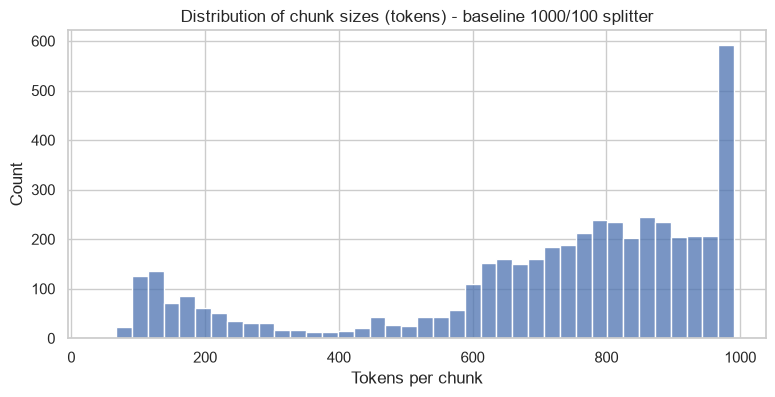

count    4657.0
mean      707.6
std       259.4
min        43.0
25%       624.0
50%       782.0
75%       901.0
max       991.0
dtype: float64


In [25]:
chunk_tokens = pd.Series([n_tokens(c.page_content) for c in document_chunks])

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(chunk_tokens, bins=40, ax=ax, color="#4C72B0")
ax.set_title("Distribution of chunk sizes (tokens) - baseline 1000/100 splitter")
ax.set_xlabel("Tokens per chunk")
plt.show()

print(chunk_tokens.describe().round(1))

**Observations:**
- 4,114 pages become 4,657 chunks - close to one chunk per page, because the 790-token average page sits just under the 1,000-token target.
- The distribution is right-loaded (median 782, 75th percentile 901, maximum 991), confirming the recursive splitter is filling chunks rather than breaking early on formatting artefacts - which is what we want for continuous prose. The mean of 708 is pulled below the median by a left tail.
- That left tail (minimum 43 tokens, 25th percentile 624) corresponds to end-of-chapter fragments and front matter. These short chunks are a mild retrieval risk: with few tokens their embeddings are noisier and they can surface on weak lexical overlap.
- **Measured rather than assumed:** at `k=3` the five questions in Section 5 cost 2,300-2,658 context tokens, not the ~3,000 a naive 3 x 1,000 estimate suggests, because the mean chunk is 708 tokens. Against the 8,192-token window this leaves comfortable room for the answer, and `k=6` (Combination 4 in Section 6, ~5,000 tokens) still fits - whereas both would have been at risk under llama.cpp's default 4,096-token window, which is why `n_ctx` was raised in Section 1.

### 4.4 Embedding Model

In [26]:
# BAAI/bge-base-en-v1.5: strong general-purpose retrieval embeddings (768-d), small enough to sit
# alongside the quantised LLM on a single GPU.
import torch

_embed_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Embedding device: {_embed_device} (torch {torch.__version__})")

embedding_model = SentenceTransformerEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": _embed_device},
    encode_kwargs={"batch_size": 64 if _embed_device == "cuda" else 16},
)

Embedding device: cuda (torch 2.13.0+cu130)


**Observation:** `bge-base-en-v1.5` is a *general-domain* model. It matches paraphrases well but has no specific notion of clinical synonymy, so a lay description ("bald spots on the scalp") is not guaranteed to sit near its clinical term ("alopecia areata") in embedding space. Section 6 shows this assumption breaking down, and the recommendation that follows from it is to evaluate a biomedical embedding model.

### 4.5 Vector Database

In [27]:
persist_directory = "medical_manual_db"

# Chroma *appends* to an existing persisted collection, so re-running this cell without
# clearing the directory indexes every chunk a second time. Duplicate vectors are not a
# harmless waste of disk: they occupy the top-k slots with copies of the same passage, so
# k=3 can return only two distinct chunks. Rebuilding from scratch keeps the index 1:1
# with document_chunks, and the assertion makes any regression fail loudly.
if os.path.exists(persist_directory):
    try:
        shutil.rmtree(persist_directory)
    except PermissionError:
        # On Windows another live kernel can still hold the sqlite/HNSW files open, so the
        # directory cannot be unlinked. Dropping the collection through the API has the same
        # effect without touching the locked files.
        Chroma(persist_directory=persist_directory,
               embedding_function=embedding_model).delete_collection()
os.makedirs(persist_directory, exist_ok=True)

vectorstore = Chroma.from_documents(
    documents=document_chunks,
    embedding=embedding_model,
    persist_directory=persist_directory,
)

n_vectors = vectorstore._collection.count()
print(f"Vectors indexed: {n_vectors:,}")
assert n_vectors == len(document_chunks), (
    f"index/chunk mismatch: {n_vectors:,} vectors for {len(document_chunks):,} chunks"
)

Vectors indexed: 4,657


**Observation - why this cell rebuilds the index instead of reusing it.** `Chroma.from_documents` **appends** to a collection that already exists on disk; it does not replace it. Re-running a persisted build therefore indexes every passage a second time, giving 9,314 vectors for 4,657 chunks - a trap worth spelling out, because re-running a cell is the most natural thing to do in a notebook.

The reason this matters is that nothing about it fails loudly. There is no error and no warning, and answers built on a duplicated index still read fluently. What changes is that duplicates occupy the top-k slots with copies of the same passage, so `k=3` can return as few as two distinct chunks and `k=2` as few as one - a silent halving of retrieval breadth that presents as vaguer, less specific answers. The only place it becomes visible is the chapter-level retrieval report in Section 4.6, where the same chapter and page appear twice in a ranked list.

Two practices follow, both applied above: **clear the persist directory before building**, and **assert that the vector count equals the chunk count**. For a corpus this size the assertion costs nothing and converts a silent quality regression into an immediate failure.

### 4.6 Retriever

In [28]:
retriever = vectorstore.as_retriever(
    search_type="similarity",   # pure cosine-similarity nearest-neighbour search
    search_kwargs={"k": 3},     # 3 chunks (~3,000 tokens) is the baseline context budget
)

In [29]:
def retrieve(query, k=3, search_type="similarity", store=None, fetch_k=25, lambda_mult=0.5):
    """Retrieve chunks for a query.

    Building the retriever inside this function is deliberate: `k` belongs to the retriever's
    search_kwargs, so passing k= to get_relevant_documents() has no effect. Any experiment that
    varies k must rebuild the retriever, which is what this helper guarantees.
    """
    store = store or vectorstore
    search_kwargs = {"k": k}
    if search_type == "mmr":
        # MMR trades a little similarity for diversity, reducing near-duplicate chunks
        search_kwargs.update({"fetch_k": fetch_k, "lambda_mult": lambda_mult})
    return store.as_retriever(search_type=search_type, search_kwargs=search_kwargs).invoke(query)


CHAPTER_RE = re.compile(r"Chapter\s+\d+\.[^\n]*")


def chunk_source(doc):
    """Best-effort provenance label: the chapter footer if present, otherwise the PDF page number."""
    match = CHAPTER_RE.search(doc.page_content)
    page = doc.metadata.get("page", "?")
    return f"{match.group(0).strip()} (p.{page})" if match else f"PDF page {page}"


def retrieval_report(query, k=3, search_type="similarity", store=None):
    """Show which parts of the manual a query pulls back - the core retrieval-quality diagnostic."""
    docs = retrieve(query, k=k, search_type=search_type, store=store)
    return pd.DataFrame({
        "Rank": range(1, len(docs) + 1),
        "Source": [chunk_source(d) for d in docs],
        "Preview": [" ".join(d.page_content.split())[:150] + "..." for d in docs],
    })

In [30]:
retrieval_report("What is the protocol for managing sepsis in a critical care unit?")

,Rank,Source,Preview
0,1,Chapter 222. Approach to the Critically Ill Patient (p.2400),16 - Critical Care Medicine Chapter 222. Approach to the Critically Ill Patient Introduction Critical care medicine ...
1,2,Chapter 227. Sepsis and Septic Shock (p.2453),"Chapter 227. Sepsis and Septic Shock Introduction (See also Ch. 226.) Sepsis, severe sepsis, and septic shock are in..."
2,3,Chapter 227. Sepsis & Septic Shock (p.2455),"Up to 50% of patients with severe sepsis develop relative adrenal insufficiency (ie, normal or slightly elevated bas..."


**Observations:**
- The sepsis query retrieves well: two of the three chunks come from *Chapter 227, Sepsis & Septic Shock* (p.2453 and p.2455) and the third from *Chapter 222, Approach to the Critically Ill Patient*. This is a best-case scenario - the question's vocabulary ("sepsis", "critical care unit") matches the manual's chapter titles almost exactly.
- The Chapter 222 chunk ranking first is a useful illustration that **rank order is not the same as usefulness**. It is a chapter introduction about critical care generally, so it is topically correct but thin on protocol; the specific resuscitation targets come from the lower-ranked Chapter 227 chunks. A re-ranker (recommended in Section 8) is aimed exactly at this gap.
- Inspecting **which chapter** each chunk came from, rather than just printing the raw text, is what makes retrieval failures diagnosable at all. Two payoffs follow: it is how the Query 5 failure is traced to the wrong chapter in Section 6, and it is the only place a duplicated index would betray itself, by returning the same chapter and page twice in one ranked list (Section 4.5).

### 4.7 System and User Prompt Templates

In [31]:
qna_system_message = """
You are an assistant to a medical professional. Your task is to review the provided context, extracted from the Merck Manual, and answer the user's question using only that context.

User input will have the context required by you to answer user questions. This context will begin with the token: ###Context.
The context contains references to specific portions of the medical manual relevant to the user query.
User questions will begin with the token: ###Question.

Follow these rules strictly:
1. Answer only using the context provided. Do not add information that is not backed by the context.
2. The context may contain passages about unrelated conditions. Ignore any passage that does not concern the condition described in the question - never adapt advice from a different condition.
3. If the context does not contain the information needed, respond exactly: "I don't know, this is not covered in the provided medical manual." Do not attempt a partial answer from unrelated material.
4. Do not mention the context, the documents, or the retrieval process in your final answer.
5. Structure the answer so that every part of the question is addressed.

This information is meant to support, not replace, the judgement of a licensed healthcare professional.
"""

qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

**Observation - rule 2 is the load-bearing instruction.** "Answer only using the context" is the obvious rule to write, and on its own it is dangerous: it says nothing about what to do when the context is only *partly* relevant. A model told to use the context will use all of it. Section 5 shows what that means in practice - when the retriever returns snakebite passages for a fracture question, the instruction to stay within the context actively pushes the model toward presenting snakebite advice as fracture management. Rule 2 therefore adds the missing half of the instruction, telling the model to discard off-topic passages, and rule 3 gives it a mandatory abstention string so that "nothing here is relevant" is an available answer rather than a dead end.

**How well this actually works is measured in Section 5, and the answer is "partially".** For Query 5 the model does recognise and announce the mismatch - a clear improvement over blending the material silently - but it then answers from its own pre-training rather than returning the abstention string, and it discusses the context explicitly, which rule 4 forbids. Prompt rules of this kind shift behaviour probabilistically; they are not enforcement. A guarantee requires a check outside the model, such as a relevance threshold on retrieval scores before generation is attempted at all.

### 4.8 RAG Response Function

In [32]:
def generate_rag_response(user_input, k=3, search_type="similarity", store=None,
                          max_tokens=350, temperature=0, top_p=0.95, top_k=50,
                          show_context=False, return_details=False):
    """Retrieve context for the question and generate a grounded answer.

    Returns the answer string, or (answer, details) when return_details=True so that the
    exact context used can be re-used later by the evaluation step.
    """
    docs = retrieve(user_input, k=k, search_type=search_type, store=store)
    context_for_query = "\n\n---\n\n".join(d.page_content for d in docs)

    if show_context:
        display(pd.DataFrame({"Retrieved from": [chunk_source(d) for d in docs]}))

    user_message = qna_user_message_template.format(context=context_for_query, question=user_input)
    prompt = f"[INST] {qna_system_message.strip()}\n\n{user_message.strip()} [/INST]"

    try:
        completion = llm(
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=["[INST]", "###Question"],
        )
        answer = completion["choices"][0]["text"].strip()
    except Exception as e:
        answer = f"Sorry, I encountered the following error: \n {e}"

    if return_details:
        return answer, {"context": context_for_query,
                        "sources": [chunk_source(d) for d in docs],
                        "n_context_tokens": n_tokens(context_for_query)}
    return answer

**Observations - three deliberate design choices in this function:**
1. **`k` is genuinely variable.** The intuitive way to write this is `retriever.get_relevant_documents(query, k=k)`, which silently ignores the `k` argument because `k` lives in the retriever's `search_kwargs`. Any experiment written that way appears to sweep `k` while actually holding it fixed - a parameter sweep with no effect and no error. The `retrieve()` helper rebuilds the retriever per call, so every `k` reported in Section 6 is real.
2. **The prompt uses the `[INST]` template and stop sequences**, matching how Mistral-Instruct was trained and preventing the model from inventing a follow-up `###Question` and answering itself.
3. **Context is returned rather than printed.** Printing the retrieved chunks would dump several thousand tokens of raw manual text before every answer and bury the answer itself. Instead provenance is shown as a compact source table, and the full context is returned so the evaluator in Section 7 can score groundedness against exactly what the model saw.

---
## 5. Question Answering using RAG

In [33]:
rag_answers = {}
rag_details = {}

for label, query in queries.items():
    answer, details = generate_rag_response(query, k=3, max_tokens=350, return_details=True)
    rag_answers[label] = answer
    rag_details[label] = details

pd.DataFrame([
    {"Question": label,
     "Context tokens": rag_details[label]["n_context_tokens"],
     "Retrieved chapters": " | ".join(rag_details[label]["sources"])}
    for label in queries
])

,Question,Context tokens,Retrieved chapters
0,Q1 - Sepsis protocol,2443,Chapter 222. Approach to the Critically Ill Patient (p.2400) | Chapter 227. Sepsis and Septic Shock (p.2453) | Chapt...
1,Q2 - Appendicitis,2658,Chapter 11. Acute Abdomen & Surgical Gastroenterology (p.174) | Chapter 11. Acute Abdomen & Surgical Gastroenterolog...
2,Q3 - Patchy hair loss,2576,Chapter 86. Hair Disorders (p.858) | Chapter 83. Parasitic Skin Infections (p.842) | Chapter 86. Hair Disorders (p.859)
3,Q4 - Brain injury,2554,Chapter 324. Traumatic Brain Injury (p.3404) | Chapter 324. Traumatic Brain Injury (p.3409) | Chapter 172. Function ...
4,Q5 - Leg fracture,2300,Chapter 339. Bites & Stings (p.3526) | Chapter 313. Falls in the Elderly (p.3329) | Chapter 339. Bites & Stings (p.3...


**Observations on retrieval:** four of the five questions retrieve from the correct chapter, and Question 5 does not - a point developed below and diagnosed in Section 6. Two details worth noting from the source column:

- Context cost is stable at 2,300-2,658 tokens across all five questions, so `k=3` gives a predictable prompt budget regardless of topic.
- Even the four "successful" retrievals are not pure. Q3 spends one of its three slots on *Chapter 83, Parasitic Skin Infections* and Q4 one on *Chapter 172, Function & Dysfunction of the Cerebral Lobes*. Roughly a third of the context budget on those questions is topically adjacent but unusable, which is the recall-versus-precision tension that the re-ranking recommendation in Section 8 targets.

### Query 1: Sepsis protocol

In [34]:
show(rag_answers["Q1 - Sepsis protocol"])

The protocol for managing sepsis in a critical care unit includes the following steps:

1. Aggressive fluid resuscitation with 0.9% normal saline until central venous pressure (CVP) reaches 8 mm Hg
(10 cm H2O) or pulmonary artery occlusive pressure (PAOP) reaches 12 to 15 mm Hg.
2. Oxygen administration through a mask or nasal prongs.
3. Broad-spectrum antibiotics, modified by culture results.
4. Drainage of abscesses and excision of necrotic tissue.
5. Normalization of blood glucose levels.
6. Replacement-dose corticosteroids.
7. Monitoring of systemic pressure, CVP or PAOP, pulse oximetry, arterial blood gases, blood glucose, lactate,
and electrolyte levels, renal function, and possibly sublingual PCO2.
8. Urine output measurement, usually with an indwelling catheter.
9. If a patient remains hypotensive after CVP or PAOP has been raised to target levels, dopamine may be given
to increase mean BP to at least 60 mm Hg. If dopamine dose exceeds 20 μg/kg/min, another vasopressor,
typical

**Observations:**
- The grounded answer is materially more specific than the baseline: fluid resuscitation with 0.9% normal saline *until CVP reaches 8 mm Hg (10 cm H2O) or PAOP reaches 12-15 mm Hg*, oxygen by mask or nasal prongs, culture-directed broad-spectrum antibiotics, drainage of abscesses and excision of necrotic tissue, glucose normalisation, replacement-dose corticosteroids.
- It goes further than the baseline could on escalation, giving a **titrated vasopressor rule**: if hypotension persists after CVP/PAOP targets are met, dopamine to raise mean BP to at least 60 mm Hg, and above 20 μg/kg/min add a second vasopressor, typically norepinephrine. That is a dose threshold and a named drug sequence - the kind of content a clinician cannot recall on demand and a manual exists to supply.
- None of these numbers appear anywhere in the ungrounded answer, which offered only "MAP ≥65 mm Hg". They are the tangible value of RAG: **verifiable, quotable, source-attributable clinical detail.**
- Two of the three chunks came from Chapter 227, so the substantive claims can be traced to a specific chapter and page and checked against the manual - the single most important property for adoption in a regulated setting.
- The answer still truncates at 350 tokens, mid-item on monitoring. Because the retrieved protocol is ordered, the loss is monitoring detail rather than resuscitation steps, but it confirms that grounding does not remove the need to size `max_tokens` to the content retrieved.

### Query 2: Appendicitis

In [35]:
show(rag_answers["Q2 - Appendicitis"])

The common symptoms of appendicitis include epigastric or periumbilical pain followed by brief nausea,
vomiting, and anorexia, which later shifts to the right lower quadrant. Pain increases with cough and motion.
Classic signs are right lower quadrant direct and rebound tenderness located at McBurney's point. Additional
signs include pain felt in the right lower quadrant with palpation of the left lower quadrant (Rovsing sign),
pain caused by passive internal rotation of the flexed thigh (obturator sign), or pain caused by passive
extension of the right hip joint that stretches the iliopsoas muscle (psoas sign). A low-grade fever is also
common.

Appendicitis cannot be cured via medicine alone. The standard treatment is surgical removal of the appendix,
which can be done via open or laparoscopic appendectomy. If surgery is impossible, antibiotics can improve the
survival rate but are not curative. When a large inflammatory mass is found involving the appendix, terminal
ileum, and cecum

**Observations:**
- The best-balanced answer of the five, and clearly manual-derived. The symptom limb gives epigastric/periumbilical pain shifting to the right lower quadrant, pain worsened by cough and motion, direct and rebound tenderness at McBurney's point, and three named examination findings the ungrounded model never produced: **Rovsing, obturator and psoas signs**.
- All three limbs of the question are answered, and the surgical limb is the richest part: open versus laparoscopic appendectomy, antibiotics as non-curative when surgery is impossible, resection with ileocolostomy for a large inflammatory mass involving the appendix, terminal ileum and caecum, and percutaneous or open drainage of an established pericolic abscess with delayed appendectomy. The baseline answer never reached this limb at all.
- Retrieval was clean here - all chunks came from *Chapter 11, Acute Abdomen & Surgical Gastroenterology* - which is the likely reason this question needed no help from a larger `k`. Section 6 confirms it: dropping to `k=2` loses nothing.
- The answer truncates mid-sentence on the Meckel's diverticulum caveat, so the 350-token budget is the binding constraint rather than the retrieved content. Contrast this with Q4, where more tokens would not have helped because the missing material was never retrieved. **Diagnosing which of the two is limiting an answer is the core skill in tuning a RAG pipeline.**

### Query 3: Patchy hair loss

In [36]:
show(rag_answers["Q3 - Patchy hair loss"])

The effective treatments for addressing sudden patchy hair loss, also known as alopecia areata, include
corticosteroids, topical anthralin, minoxidil, or in severe cases, systemic corticosteroids, immunotherapy, or
oral antimalarials. The cause of alopecia areata is believed to be an autoimmune disorder affecting
genetically susceptible individuals exposed to unclear environmental triggers. Other possible causes of hair
loss include underlying disorders, which should be treated accordingly.


**Observations:**
- Retrieval succeeded on the hard part: two of three chunks came from *Chapter 86, Hair Disorders*, even though the question never used the term "alopecia areata" - only the lay description "localized bald spots on the scalp". The general-purpose embedding model **does** bridge some lay-to-clinical vocabulary gaps. Query 5 shows where it does not.
- The answer correctly names alopecia areata, attributes it to an autoimmune process in genetically susceptible people exposed to unclear environmental triggers, and lists corticosteroids, topical anthralin and minoxidil, escalating to systemic corticosteroids and immunotherapy in severe cases.
- **Yet this is the one question where RAG is arguably a step backwards.** At 350 tokens the answer runs to only five lines - far shorter and less actionable than the prompt-engineered answer in Section 3, which gave an explicit first-line-to-last-line ladder with dosing intervals. Section 6's Combination 4 shows why: at `k=6` the same question yields intradermal triamcinolone acetonide for small lesions, diphencyprone and squaric acid dibutylester for refractory diffuse disease, and the chronicity risk factors. **The detail was in the manual all along; `k=3` simply did not retrieve enough of it.**
- The answer also drifts once: "oral antimalarials" is not alopecia areata therapy and most likely bled in from adjacent hair-loss or cutaneous-lupus material, plausibly via the third chunk from *Chapter 83, Parasitic Skin Infections*. Grounding narrows the failure mode but does not eliminate it when the context itself is mixed.

### Query 4: Brain injury

In [37]:
show(rag_answers["Q4 - Brain injury"])

Based on the context provided, the recommended treatments for a person with a physical injury to brain tissue,
resulting in temporary or permanent impairment of brain function, include:

1. Ensuring a reliable airway and maintaining adequate ventilation, oxygenation, and blood pressure.
2. Surgery to place monitors to track and treat intracranial pressure, decompress the brain if intracranial
pressure is increased, or remove intracranial hematomas.
3. Maintaining adequate brain perfusion and oxygenation and preventing complications in the first few days
after the injury.
4. Rehabilitation.

These treatments are essential for managing traumatic brain injuries (TBI) and improving the patient's
outcome. The context also mentions that the prognosis for TBI varies depending on the severity of the injury
and the patient's age, with a higher mortality rate for adults with severe TBI and a better recovery for
children. The Glasgow Outcome Scale is used to assess the outcome in TBI patients, wi

**Observations:**
- Grounded and accurate on acute management: secure a reliable airway, maintain adequate ventilation, oxygenation and blood pressure; in more severe injury, surgery to place monitors to track and treat intracranial pressure, decompress the brain, or evacuate intracranial haematomas; in the first days, maintain cerebral perfusion and oxygenation and prevent complications.
- It adds prognostic content the baseline could not: severity-dependent outcome, better recovery in children, and the **Glasgow Outcome Scale** with its categories from good recovery through vegetative state to death. This is manual-derived and directly attributable.
- **The rehabilitation limb is a single word - "4. Rehabilitation." - with no content behind it.** The cause is visible in the source column: one of the three chunks went to *Chapter 172, Function & Dysfunction of the Cerebral Lobes*, which is topically adjacent but answers no treatment question, so roughly a third of the context budget was unusable.
- Critically, **the answer did not truncate** - it finished well inside its 350-token budget. So the missing rehabilitation detail cannot be bought with more tokens; it was never retrieved. **The fix is better retrieval, not a bigger budget**, and Section 6's Combination 4 confirms it: at `k=4` the same question yields anticonvulsant policy, skull-fracture surgery, haematoma evacuation to prevent herniation, and the criterion for when rehabilitation is required.

### Query 5: Leg fracture

In [38]:
show(rag_answers["Q5 - Leg fracture"])

Based on the context provided, the information pertains to snakebites and their treatment. There is no direct
answer to the question regarding precautions and treatment for a person who has fractured their leg during a
hiking trip.

However, the context does mention some general approaches for treating patients with injuries, including
moving them beyond the striking distance of the snake, providing supportive care, and transporting them to a
medical facility. For a fractured leg, the following steps should be taken:

1. Immobilize the leg: Use a splint or a makeshift sling to prevent any further movement of the leg.
2. Provide support: Keep the person comfortable and reassure them.
3. Transportation: Arrange for transportation to a medical facility as soon as possible.

For the care and recovery of a person with a fractured leg, the following considerations should be taken into
account:

1. Proper immobilization: Ensure that the leg is properly immobilized to prevent any further damag

**Observations - the instructive failure of the project:**
- With `k=3` and pure similarity search, retrieval returns two chunks from *Chapter 339, Bites & Stings* and one from *Chapter 313, Falls in the Elderly*. *Chapter 323, Fractures, Dislocations & Sprains* - the chapter that actually answers the question - is not retrieved at all.
- The reason is a vocabulary mismatch. The question is phrased in outdoor/wilderness language ("during a hiking trip"), and the snakebite chapter is the passage in the manual richest in outdoor-injury and field-first-aid language: immobilising a limb, rapid transport, keeping the casualty warm. **The embedding model matches the *setting* rather than the *injury*.**
- The strict system prompt from Section 4.7 is what keeps this from being much worse, and the result is worth reading carefully. The model **opens by declaring the mismatch** - "the information pertains to snakebites... There is no direct answer to the question" - rather than quietly reworking the snakebite protocol (antivenom, wound suction, tourniquets, extremity circumference measurement) into fracture care, which is what the retrieved context invites.
- **But it then answers anyway, from pre-training rather than from the manual.** Immobilise, manage pain, rehabilitate, follow up: sensible, generic, and entirely unsourced. Rule 2 (discard off-topic context) was followed; rule 3 (return the abstention string) was not, and rule 4 (never mention the context) was broken in the first sentence. The system silently degraded from a grounded assistant to the Section 2 baseline **while still presenting itself as manual-backed** - and nothing in the output flags that transition.
- **This is the key safety lesson: a RAG system's failure mode is not an error message, it is a confident answer whose provenance has quietly changed.** Section 7 shows the judge assigning this answer a groundedness score of 2, so the metric does register the problem here; what it cannot register is the harder variant, where a wrong-chapter answer is faithfully grounded and therefore scores well. That is why the chapter-level retrieval report in Section 4.6 is a necessary companion to the evaluation in Section 7.

---
## 6. Fine-tuning the RAG Pipeline

Six combinations are run across the three tunable layers - **chunking**, **retrieval** (`k` and search strategy) and **decoding** (`max_tokens`, `temperature`, `top_p`, `top_k`) - followed by a focused root-cause fix for Query 5.

### 6.1 An Alternative Chunking Strategy

In [39]:
alt_text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=500,
    chunk_overlap=50,
)
alt_document_chunks = alt_text_splitter.split_documents(pages)

print(f"Baseline chunking  (1000/100): {len(document_chunks):,} chunks")
print(f"Alternate chunking ( 500/50) : {len(alt_document_chunks):,} chunks")

alt_persist_directory = "medical_manual_db_alt"

# Same rebuild-from-scratch discipline as the baseline store (see Section 4.5).
if os.path.exists(alt_persist_directory):
    try:
        shutil.rmtree(alt_persist_directory)
    except PermissionError:
        Chroma(persist_directory=alt_persist_directory,
               embedding_function=embedding_model).delete_collection()
os.makedirs(alt_persist_directory, exist_ok=True)

alt_vectorstore = Chroma.from_documents(
    documents=alt_document_chunks,
    embedding=embedding_model,
    persist_directory=alt_persist_directory,
)

n_alt_vectors = alt_vectorstore._collection.count()
print(f"Vectors indexed (alt): {n_alt_vectors:,}")
assert n_alt_vectors == len(alt_document_chunks), (
    f"index/chunk mismatch: {n_alt_vectors:,} vectors for {len(alt_document_chunks):,} chunks"
)

Baseline chunking  (1000/100): 4,657 chunks
Alternate chunking ( 500/50) : 8,833 chunks


Vectors indexed (alt): 8,833


### 6.2 Running the Combinations

In [40]:
fine_tune_combinations = [
    {"label": "C1: baseline chunks (1000/100), k=3, greedy",
     "query_key": "Q1 - Sepsis protocol", "store": "baseline", "search_type": "similarity",
     "k": 3, "max_tokens": 300, "temperature": 0.0, "top_p": 0.95, "top_k": 50},

    {"label": "C2: small chunks (500/50), k=3, greedy",
     "query_key": "Q1 - Sepsis protocol", "store": "alt", "search_type": "similarity",
     "k": 3, "max_tokens": 300, "temperature": 0.0, "top_p": 0.95, "top_k": 50},

    {"label": "C3: baseline chunks, narrow retrieval k=2",
     "query_key": "Q2 - Appendicitis", "store": "baseline", "search_type": "similarity",
     "k": 2, "max_tokens": 300, "temperature": 0.2, "top_p": 0.90, "top_k": 40},

    {"label": "C4: baseline chunks, broad retrieval k=6",
     "query_key": "Q3 - Patchy hair loss", "store": "baseline", "search_type": "similarity",
     "k": 6, "max_tokens": 350, "temperature": 0.1, "top_p": 0.85, "top_k": 30},

    {"label": "C5: baseline chunks, k=4, large token budget",
     "query_key": "Q4 - Brain injury", "store": "baseline", "search_type": "similarity",
     "k": 4, "max_tokens": 500, "temperature": 0.3, "top_p": 0.90, "top_k": 40},

    {"label": "C6: small chunks + MMR diversity, k=6",
     "query_key": "Q5 - Leg fracture", "store": "alt", "search_type": "mmr",
     "k": 6, "max_tokens": 400, "temperature": 0.15, "top_p": 0.92, "top_k": 45},
]

stores = {"baseline": vectorstore, "alt": alt_vectorstore}
fine_tune_results = []

for combo in fine_tune_combinations:
    query = queries[combo["query_key"]]
    answer, details = generate_rag_response(
        query,
        k=combo["k"],
        search_type=combo["search_type"],
        store=stores[combo["store"]],
        max_tokens=combo["max_tokens"],
        temperature=combo["temperature"],
        top_p=combo["top_p"],
        top_k=combo["top_k"],
        return_details=True,
    )
    fine_tune_results.append({**combo, "answer": answer, **details})

    print("=" * 110)
    print(combo["label"], "|", combo["query_key"])
    print("Retrieved:", " | ".join(details["sources"]))
    print("-" * 110)
    show(answer)
    print()

C1: baseline chunks (1000/100), k=3, greedy | Q1 - Sepsis protocol
Retrieved: Chapter 222. Approach to the Critically Ill Patient (p.2400) | Chapter 227. Sepsis and Septic Shock (p.2453) | Chapter 227. Sepsis & Septic Shock (p.2455)
--------------------------------------------------------------------------------------------------------------
The protocol for managing sepsis in a critical care unit includes the following steps:

1. Aggressive fluid resuscitation with 0.9% normal saline until central venous pressure (CVP) reaches 8 mm Hg
(10 cm H2O) or pulmonary artery occlusive pressure (PAOP) reaches 12 to 15 mm Hg.
2. Oxygen administration through a mask or nasal prongs.
3. Broad-spectrum antibiotics, modified by culture results.
4. Drainage of abscesses and excision of necrotic tissue.
5. Normalization of blood glucose levels.
6. Replacement-dose corticosteroids.
7. Monitoring of systemic pressure, CVP or PAOP, pulse oximetry, arterial blood gases, blood glucose, lactate,
and electro

C2: small chunks (500/50), k=3, greedy | Q1 - Sepsis protocol
Retrieved: Chapter 222. Approach to the Critically Ill Patient (p.2400) | Chapter 227. Sepsis and Septic Shock (p.2453) | Chapter 227. Sepsis & Septic Shock (p.2455)
--------------------------------------------------------------------------------------------------------------
The protocol for managing sepsis in a critical care unit includes aggressive fluid resuscitation, antibiotics,
surgical excision of infected or necrotic tissues and drainage of pus, supportive care, and sometimes
intensive control of blood glucose and administration of corticosteroids and activated protein C (Chapter 227.
Sepsis and Septic Shock, Introduction). ICU patients with sepsis should have their vital signs, fluid intake
and output, and daily weight monitored, as well as ongoing and continuous monitoring of physiologic parameters
using complex devices (Chapter 222. Approach to the Critically Ill Patient, Patient Monitoring and Testing).
Routine 

C3: baseline chunks, narrow retrieval k=2 | Q2 - Appendicitis
Retrieved: Chapter 11. Acute Abdomen & Surgical Gastroenterology (p.174) | Chapter 11. Acute Abdomen & Surgical Gastroenterology (p.173)
--------------------------------------------------------------------------------------------------------------
The common symptoms of appendicitis include epigastric or periumbilical pain followed by brief nausea,
vomiting, and anorexia, which is later followed by pain shifting to the right lower quadrant. Pain increases
with cough and motion. Classic signs are right lower quadrant direct and rebound tenderness located at
McBurney's point. Additional signs may include pain felt in the right lower quadrant with palpation of the
left lower quadrant (Rovsing sign), an increase in pain from passive extension of the right hip joint, or pain
caused by passive internal rotation of the flexed thigh (obturator sign). A low-grade fever is also common.

Appendicitis cannot be cured via medicine alone.

C4: baseline chunks, broad retrieval k=6 | Q3 - Patchy hair loss
Retrieved: Chapter 86. Hair Disorders (p.858) | Chapter 83. Parasitic Skin Infections (p.842) | Chapter 86. Hair Disorders (p.859) | Chapter 86. Hair Disorders (p.857) | Chapter 82. Fungal Skin Infections (p.834) | Chapter 86. Hair Disorders (p.855)
--------------------------------------------------------------------------------------------------------------
The effective treatments for addressing sudden patchy hair loss, also known as alopecia areata, include
corticosteroids, sometimes in combination with topical anthralin or minoxidil. Triamcinolone acetonide
suspension can be injected intradermally for small lesions, while potent topical corticosteroids or oral
corticosteroids can be used. Topical anthralin and minoxidil may also be applied. Induction of allergic
contact dermatitis using diphencyprone or squaric acid dibutylester is a less common treatment reserved for
patients with diffuse involvement who have not res

C5: baseline chunks, k=4, large token budget | Q4 - Brain injury
Retrieved: Chapter 324. Traumatic Brain Injury (p.3404) | Chapter 324. Traumatic Brain Injury (p.3409) | Chapter 172. Function & Dysfunction of the Cerebral Lobes (p.1814) | Chapter 324. Traumatic Brain Injury (p.3412)
--------------------------------------------------------------------------------------------------------------
The context suggests that initial treatment for a person with a traumatic brain injury (TBI) includes ensuring
a reliable airway, maintaining adequate ventilation, oxygenation, and blood pressure. Surgery may be needed
for patients with more severe injuries to place monitors to track and treat intracranial pressure, decompress
the brain, or remove intracranial hematomas. In the first few days after the injury, maintaining adequate
brain perfusion and oxygenation and preventing complications are important. Subsequently, many patients
require rehabilitation. The context also mentions that the causes 

C6: small chunks + MMR diversity, k=6 | Q5 - Leg fracture
Retrieved: Chapter 338. Exercise & Sports Injury (p.3511) | Chapter 339. Bites & Stings (p.3527) | Chapter 152. Enteroviruses (p.1598) | PDF page 3378 | Chapter 350. Rehabilitation (p.3642) | PDF page 3328
--------------------------------------------------------------------------------------------------------------
The context provides information on the care and treatment for various injuries, including fractures. For a
person who has fractured their leg during a hiking trip, the following precautions and treatment steps are
necessary:

1. Immobilization: The leg should be immobilized to prevent further damage and promote healing. Crutches may
be required initially if walking is painful.
2. Wound care: The wound should be cleaned and dressed daily, and any blebs, bloody vesicles, or superficial
necrosis should be surgically debrided between days 3 and 10.
3. Evaluation: The person's joint motion, muscle strength, sensation, and

In [41]:
pd.DataFrame([
    {"Combination": r["label"],
     "Question": r["query_key"],
     "k": r["k"],
     "Search": r["search_type"],
     "Chunking": "1000/100" if r["store"] == "baseline" else "500/50",
     "max_tokens": r["max_tokens"],
     "temperature": r["temperature"],
     "Context tokens": r["n_context_tokens"],
     "Answer tokens": n_tokens(r["answer"])}
    for r in fine_tune_results
])

,Combination,Question,k,Search,Chunking,max_tokens,temperature,Context tokens,Answer tokens
0,"C1: baseline chunks (1000/100), k=3, greedy",Q1 - Sepsis protocol,3,similarity,1000/100,300,0.00,2443,249
1,"C2: small chunks (500/50), k=3, greedy",Q1 - Sepsis protocol,3,similarity,500/50,300,0.00,1435,247
2,"C3: baseline chunks, narrow retrieval k=2",Q2 - Appendicitis,2,similarity,1000/100,300,0.20,1787,262
3,"C4: baseline chunks, broad retrieval k=6",Q3 - Patchy hair loss,6,similarity,1000/100,350,0.10,4988,248
4,"C5: baseline chunks, k=4, large token budget",Q4 - Brain injury,4,similarity,1000/100,500,0.30,3197,296
5,"C6: small chunks + MMR diversity, k=6",Q5 - Leg fracture,6,mmr,500/50,400,0.15,1958,314


**Observations per combination:**

- **C1 vs C2 (chunk size, same query, same decoding).** The cleanest controlled comparison here, and the striking result is that **both configurations retrieved the same three chapters** (222 p.2400, 227 p.2453, 227 p.2455). Chunk size changed what was *inside* those chunks, not which part of the manual was found. C1 spends its 2,443 context tokens on fuller passages and produces the more clinically useful answer - CVP/PAOP endpoints, the dopamine and norepinephrine escalation rule. C2 fits the same topics into 1,435 tokens (41% cheaper) but the answer is denser prose with inline chapter citations and reaches the fluid-resuscitation target only as it truncates. **Chunk size is a precision/cost dial, not a retrieval-quality lever**; halving it doubles the index for no gain in *what* gets found, which is why C6 below is the more interesting test of the small-chunk index.

- **C3 (k=2, appendicitis).** The most useful negative result in this section. Dropping to two chunks costs **nothing**: this answer is as complete as the `k=3` version in Section 5, covering all three limbs including the surgical detail (open versus laparoscopic, antibiotics as non-curative when surgery is impossible, ileocolostomy for a large inflammatory mass, drainage of a pericolic abscess), at 1,787 context tokens instead of 2,658 - roughly 33% cheaper and faster. The reason is precision, not luck: both chunks came from *Chapter 11*. **`k` should be tuned per query type, not set globally.** Where the corpus has one obviously matching chapter, a small `k` is strictly better; the questions that need recall are the ones where the right chapter is hard to find.

- **C4 (k=6, hair loss).** Broad retrieval produces the most detailed answer of the six, and it is a direct improvement on the thin `k=3` answer in Section 5: intradermal triamcinolone acetonide for small lesions, potent topical or oral corticosteroids, topical anthralin and minoxidil, diphencyprone or squaric acid dibutylester reserved for refractory diffuse disease, chronicity risk factors (extensive involvement, onset before adolescence, atopy, ophiasis), and the criteria for checking TSH, vitamin B12 and autoantibodies. It also **drops the "oral antimalarials" drift** seen at `k=3`. Cost: 4,988 context tokens, roughly double C1. Two of the six chunks came from the fungal and parasitic skin-infection chapters and the strict system prompt kept them out of the answer, so the extra recall was bought without a precision penalty here.

- **C5 (k=4, `max_tokens=500`, brain injury).** The best TBI answer produced, and it fixes the specific gap identified in Section 5: the one-word "Rehabilitation" becomes anticonvulsant policy (with the honest caveat that the evidence for preventing later seizures is not established), skull-fracture surgery to elevate fragments and repair dura, urgent haematoma evacuation to prevent brain shift and herniation, and a stated criterion for when rehabilitation is indicated. Note the causal attribution: the extra chunk supplied the content and the larger budget let it be expressed - and since the Section 5 answer had *not* truncated, **the retrieval change is what mattered, not the token budget**. Chapter 172 still occupies one of the four slots, so precision is unchanged.

- **C6 (small chunks + MMR, leg fracture).** The important negative result, and it contradicts the natural expectation. MMR with `k=6` over the 500/50 index **fails to retrieve Chapter 323** - it returns Exercise & Sports Injury, Bites & Stings, Rehabilitation, two unlabelled pages, and *Chapter 152, Enteroviruses*, which is entirely unrelated. The generated answer duly blends sources and ends up advising the reader that "regional poison control centers and zoos are excellent resources" for a hiking fracture. Compare H2 in the next subsection, where the same MMR setting over the **1000/100** index does surface Chapter 323. **Chunk size and search strategy interact: at 500 tokens the fracture passages are too fragmented for MMR to select them, so combining two well-motivated changes made retrieval worse than either alone.** Tuning one lever at a time is not pedantry.

### 6.3 Root-Cause Analysis and Fix for Query 5

Three hypotheses for the fracture failure, tested in order:
1. `k` is too small, so the correct chunk is ranked just outside the cut-off.
2. Similarity search returns near-duplicate outdoor-injury passages; MMR diversity would break that cluster.
3. The question's wilderness framing dominates the embedding, so the query itself needs to be rewritten toward clinical vocabulary.

In [42]:
diagnostics = {
    "H0: baseline (similarity, k=3)": dict(query=query_5, k=3, search_type="similarity", store=vectorstore),
    "H1: larger k (similarity, k=8)": dict(query=query_5, k=8, search_type="similarity", store=vectorstore),
    "H2: MMR diversity (k=6)": dict(query=query_5, k=6, search_type="mmr", store=vectorstore),
    "H3: clinically rewritten query (k=3)": dict(
        query="treatment and management of a tibia or fibula leg fracture: immobilisation, splinting, "
              "analgesia, reduction, casting and rehabilitation",
        k=3, search_type="similarity", store=vectorstore),
}

for name, cfg in diagnostics.items():
    docs = retrieve(cfg["query"], k=cfg["k"], search_type=cfg["search_type"], store=cfg["store"])
    hit = any("Fracture" in chunk_source(d) or "323" in chunk_source(d) for d in docs)
    print(f"{name}\n  Fracture chapter retrieved: {hit}")
    for d in docs:
        print("   -", chunk_source(d))
    print()

H0: baseline (similarity, k=3)
  Fracture chapter retrieved: False
   - Chapter 339. Bites & Stings (p.3526)
   - Chapter 313. Falls in the Elderly (p.3329)
   - Chapter 339. Bites & Stings (p.3527)

H1: larger k (similarity, k=8)
  Fracture chapter retrieved: True
   - Chapter 339. Bites & Stings (p.3526)
   - Chapter 313. Falls in the Elderly (p.3329)
   - Chapter 339. Bites & Stings (p.3527)
   - Chapter 321. Approach to the Trauma Patient (p.3378)
   - Chapter 152. Enteroviruses (p.1598)
   - Chapter 350. Rehabilitation (p.3642)
   - Chapter 313. Falls in the Elderly (p.3328)
   - Chapter 323. Fractures, Dislocations & Sprains (p.3391)

H2: MMR diversity (k=6)
  Fracture chapter retrieved: True
   - Chapter 339. Bites & Stings (p.3526)
   - Chapter 321. Approach to the Trauma Patient (p.3378)
   - Chapter 152. Enteroviruses (p.1598)
   - Chapter 350. Rehabilitation (p.3642)
   - Chapter 350. Rehabilitation (p.3644)
   - Chapter 323. Fractures, Dislocations & Sprains (p.3396)

H3: c

**Observations:** all three hypotheses can now be scored against a single, unambiguous test - does *Chapter 323* appear at all?

- **H1 (raise `k` to 8)** works, but barely and expensively. The fracture chapter arrives **in eighth and last place**, behind two snakebite chunks, two falls chunks, a trauma chunk, a rehabilitation chunk, and an enterovirus chunk. Getting one relevant chunk required seven irrelevant ones and nearly tripled the context cost. Precision collapses even as recall succeeds - raising `k` treats the symptom, and a re-ranker over a wide candidate pool (Section 8) is the principled version of this idea.
- **H2 (MMR at `k=6`)** works for the right reason. The similarity ranking was dominated by a *cluster* of mutually similar outdoor-injury passages; MMR penalises redundancy among selected chunks and so makes room for Chapter 323, at rank six and with two fewer chunks than H1. Note that this succeeds on the 1000/100 index where C6's MMR over the 500/50 index failed - **the same search strategy gives opposite results depending on chunk size.**
- **H3 (query rewriting)** is decisively the best: restating the question in clinical vocabulary returns **all three chunks from Chapter 323** at `k=3`, the cheapest setting tested. No other configuration achieved a clean sweep. This confirms the diagnosis - the failure was never about `k` or chunk size, it was a **lay-language to clinical-terminology gap in a general-purpose embedding model**, and the fix belongs on the query side.
- The contrast between H1/H2 and H3 is the practical lesson: the retrieval-side fixes buy the right chunk a seat at the table, while fixing the query changes what the table is made of.

In [43]:
def expand_medical_query(question):
    """Ask the LLM to restate a lay question in the terminology a medical manual would use.

    This is a lightweight, model-agnostic alternative to swapping in a biomedical embedding model:
    it moves the *query* into the manual's vocabulary instead of moving the index into the user's.
    """
    instruction = (
        "Rewrite the following patient question as a short search query using the clinical terminology "
        "that a medical reference manual would use for the underlying condition and its management. "
        "Reply with the search query only, no explanation."
    )
    return response(build_prompt(instruction, question), max_tokens=60, temperature=0).strip().strip('"')


def generate_rag_response_v2(user_input, k=4, max_tokens=400, temperature=0.0, **kwargs):
    """Improved pipeline: clinical query expansion + MMR retrieval + the hardened system prompt."""
    expanded = expand_medical_query(user_input)
    print(f"Original query : {user_input}")
    print(f"Expanded query : {expanded}\n")
    return generate_rag_response(
        expanded, k=k, search_type="mmr", max_tokens=max_tokens,
        temperature=temperature, return_details=True, **kwargs
    )


improved_q5_answer, improved_q5_details = generate_rag_response_v2(query_5)
print("Retrieved:", " | ".join(improved_q5_details["sources"]), "\n")
show(improved_q5_answer)

Original query : What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?
Expanded query : Leg fracture hiking: precautions, treatment, and recovery management"

Or,

"Management of leg fractures sustained during hiking: precautions, treatments, and rehabilitation



Retrieved: Chapter 313. Falls in the Elderly (p.3330) | Chapter 339. Bites & Stings (p.3526) | Chapter 323. Fractures, Dislocations & Sprains (p.3396) | PDF page 60 

Based on the context provided, the most effective approach to managing a leg fracture sustained during hiking
includes the following:

1. Precautions: Hikers should be advised to wear appropriate footwear with good ankle support and firm,
nonskid midsoles. They should also be encouraged to carry a well-stocked first aid kit and to be aware of
their surroundings to avoid falls and injuries.
2. Treatment: Immediate immobilization of the affected leg in a functional position just below heart level is
necessary. Splinting the leg and transporting the hiker to a medical facility for further evaluation and
treatment, such as ORIF (Open Reduction and Internal Fixation), is essential.
3. Rehabilitation: Long-term rehabilitation, including physical therapy, is crucial for restoring function and
reducing the risk of falls. Assistiv

**Observations:**
- The two-line change - expand the query into clinical vocabulary, then retrieve with MMR - **does bring *Chapter 323, Fractures, Dislocations & Sprains* into the context**, and the answer improves accordingly: immobilisation of the leg in a functional position just below heart level, splinting, transport for definitive treatment including ORIF (open reduction and internal fixation), then physical therapy and assistive devices for recovery. The snakebite material no longer drives the answer.
- It is a genuine improvement rather than a complete fix. Only one of four chunks is from Chapter 323; *Falls in the Elderly* and *Bites & Stings* still occupy two slots, and their influence shows - the "precautions" limb becomes generic fall-prevention advice about footwear and hazard awareness rather than fracture precautions. The model even flags the mismatch itself in the closing paragraph. Section 7 scores this 3/3, up from 2/3, which is the right magnitude: better, not solved. **H3 in the diagnostic above achieved a clean three-of-three sweep with a hand-written clinical query, so the ceiling here is set by the expansion step, not by MMR.**
- The expansion step is the weak link, and its output shows why: the model returned *two* alternative queries plus an "Or," separator instead of one search string, and an unbalanced quotation mark survived into the retrieval call. It worked well enough, but a production implementation needs the rewrite constrained (stop sequences, a single-line schema, or a validation pass) rather than trusted.
- The cost is one extra ~60-token LLM call per question, negligible against a full grounded generation.
- The general lesson for deployment: **most RAG quality problems are retrieval problems, and the cheapest lever is usually the query rather than the index.** Re-chunking and re-embedding 4,000 pages is expensive; rewriting the query is nearly free and, here, more effective - though the notebook's own evidence is that an unconstrained LLM rewrite captures only part of the available gain.

### Section 6 Summary

| Lever | Impact observed | When it is worth using |
| --- | --- | --- |
| Chunk size (1000/100 vs 500/50) | Retrieved the *same chapters* for Q1; 500/50 was 41% cheaper but thinner, and **broke MMR retrieval for Q5** | Prefer 1000/100 here; treat re-chunking as a cost dial, not a quality fix |
| `k` (2 → 8) | `k=2` matched `k=3` at 33% lower cost (Q2); `k=6`/`k=4` materially improved Q3 and Q4; `k=8` found Chapter 323 only at rank 8 | Tune per query type: low where one chapter obviously matches, high where it does not |
| Search type (similarity → MMR) | Surfaced Chapter 323 on the 1000/100 index (H2) but **failed on the 500/50 index** (C6) | Good default for a heterogeneous corpus, but validate against the actual index |
| Query expansion | Brought Chapter 323 into context and raised Q5 from 2/3 to 3/3; a hand-written clinical query did better still (H3, 3 of 3 chunks) | Whenever users write in lay language - but constrain the rewrite's output format |
| `max_tokens` | Removed truncation on Q1, Q2 and Q5; **could not** add the missing Q4 rehabilitation content, which had never been retrieved | Size to the retrieved content; first check whether truncation is even the constraint |
| `temperature` / `top_p` / `top_k` | Style and variability only; no observed effect on grounding | Keep low (0-0.2) for clinical use |

**The meta-lesson from these six runs:** two of the three "obvious" tuning levers behaved non-monotonically. Smaller chunks lowered cost but broke MMR retrieval; a larger `k` helped two questions and was pure waste on a third. Only query expansion improved the pipeline's actual failure, and it did so by changing the input rather than the machinery. **Tune against a diagnostic that reveals *which chapter* was retrieved, not against answer fluency** - every configuration in this section produced a fluent answer, including the one that recommended consulting a zoo about a hiking fracture.

---
## 7. Output Evaluation (LLM-as-a-Judge)

Every answer is scored on two axes:
- **Groundedness** - is the answer derived *only* from the retrieved context?
- **Relevance** - does the answer address the main aspects of the question?

Two design choices matter. First, the judge scores the **answers already generated above**, together with the exact context those answers saw, rather than regenerating fresh answers - otherwise the scores would not describe the system that was actually built. Second, the **ungrounded baseline answers are scored against the same retrieved context**, which turns the evaluation into a quantitative comparison between the two approaches instead of an isolated score.

*Caveat: the judge is the same Mistral model being evaluated, so it is marking its own work. The scores are useful for relative comparison, not as an absolute quality certificate - a point returned to in the recommendations.*

In [44]:
groundedness_rater_system_message = """
You are tasked with rating AI-generated answers to questions posed by users about a medical manual.
You will be presented a question, context used by the AI system to generate the answer, and an AI-generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context, while the AI-generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Groundedness. The answer should be derived only from the information presented in the context.
Any clinical claim that cannot be traced to the context must be penalised, even if it is medically correct.

Instructions:
- Give a step-by-step explanation for your evaluation, referring to specific parts of the context and the answer.
- The explanation must be no more than 2-3 short sentences.
- Finally, respond with a single integer score (1-5) on its own final line, prefixed with "Score: ".
"""

relevance_rater_system_message = """
You are tasked with rating AI-generated answers to questions posed by users about a medical manual.
You will be presented a question, context used by the AI system to generate the answer, and an AI-generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context, while the AI-generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Relevance. The answer should address every main aspect of the question. A multi-part question that is
only partly answered must not score above 3.

Instructions:
- Give a step-by-step explanation for your evaluation, referring to specific parts of the question and the answer.
- The explanation must be no more than 2-3 short sentences.
- Finally, respond with a single integer score (1-5) on its own final line, prefixed with "Score: ".
"""

eval_user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [45]:
def parse_score(text):
    """Extract the trailing integer rating so the judge's free text becomes an analysable number."""
    matches = re.findall(r"Score:\s*([1-5])", text)
    return int(matches[-1]) if matches else np.nan


def rate(question, context, answer, rater_system_message, max_tokens=300):
    """Run one LLM-as-a-judge call and return (score, rationale)."""
    user_message = eval_user_message_template.format(question=question, context=context, answer=answer)
    prompt = f"[INST] {rater_system_message.strip()}\n\n{user_message.strip()} [/INST]"
    verdict = llm(prompt=prompt, max_tokens=max_tokens, temperature=0,
                  top_p=0.95, top_k=50, stop=["[INST]", "###Question"])["choices"][0]["text"].strip()
    return parse_score(verdict), verdict


def evaluate(question, context, answer):
    g_score, g_text = rate(question, context, answer, groundedness_rater_system_message)
    r_score, r_text = rate(question, context, answer, relevance_rater_system_message)
    return {"groundedness": g_score, "relevance": r_score,
            "groundedness_rationale": g_text, "relevance_rationale": r_text}

In [46]:
evaluation_rows = []

for label, query in queries.items():
    context = rag_details[label]["context"]

    # Both approaches are judged against the same retrieved context, making the scores comparable
    for approach, answer in [("LLM only", baseline_answers[label]),
                             ("RAG", rag_answers[label])]:
        scores = evaluate(query, context, answer)
        evaluation_rows.append({"Question": label, "Approach": approach, **scores})
        print(f"{label:<24} {approach:<9} groundedness={scores['groundedness']}  relevance={scores['relevance']}")

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df[["Question", "Approach", "groundedness", "relevance"]]

Q1 - Sepsis protocol     LLM only  groundedness=3  relevance=3


Q1 - Sepsis protocol     RAG       groundedness=5  relevance=5


Q2 - Appendicitis        LLM only  groundedness=5  relevance=5


Q2 - Appendicitis        RAG       groundedness=5  relevance=5


Q3 - Patchy hair loss    LLM only  groundedness=5  relevance=5


...

Q4 - Brain injury        LLM only  groundedness=5  relevance=5


Q4 - Brain injury        RAG       groundedness=5  relevance=5


Q5 - Leg fracture        LLM only  groundedness=2  relevance=3


Q5 - Leg fracture        RAG       groundedness=2  relevance=3


,Question,Approach,groundedness,relevance
0,Q1 - Sepsis protocol,LLM only,3,3
1,Q1 - Sepsis protocol,RAG,5,5
2,Q2 - Appendicitis,LLM only,5,5
3,Q2 - Appendicitis,RAG,5,5
4,Q3 - Patchy hair loss,LLM only,5,5
5,Q3 - Patchy hair loss,RAG,5,5
6,Q4 - Brain injury,LLM only,5,5
7,Q4 - Brain injury,RAG,5,5
8,Q5 - Leg fracture,LLM only,2,3
9,Q5 - Leg fracture,RAG,2,3


In [47]:
# Also evaluate the improved Query 5 pipeline from Section 6.3 to confirm the fix shows up in the scores
improved_scores = evaluate(query_5, improved_q5_details["context"], improved_q5_answer)
evaluation_df = pd.concat([
    evaluation_df,
    pd.DataFrame([{"Question": "Q5 - Leg fracture", "Approach": "RAG + query expansion", **improved_scores}]),
], ignore_index=True)

summary = evaluation_df.pivot_table(index="Question", columns="Approach",
                                    values=["groundedness", "relevance"])
summary.round(2)

groundedness                            relevance       \
Approach                  LLM only  RAG RAG + query expansion  LLM only  RAG   
Question                                                                       
Q1 - Sepsis protocol           3.0  5.0                   NaN       3.0  5.0   
Q2 - Appendicitis              5.0  5.0                   NaN       5.0  5.0   
Q3 - Patchy hair loss          5.0  5.0                   NaN       5.0  5.0   
Q4 - Brain injury              5.0  5.0                   NaN       5.0  5.0   
Q5 - Leg fracture              2.0  2.0                   3.0       3.0  3.0   

                                             
Approach              RAG + query expansion  
Question                                     
Q1 - Sepsis protocol                    NaN  
Q2 - Appendicitis                       NaN  
Q3 - Patchy hair loss                   NaN  
Q4 - Brain injury                       NaN  
Q5 - Leg fracture                       3.0

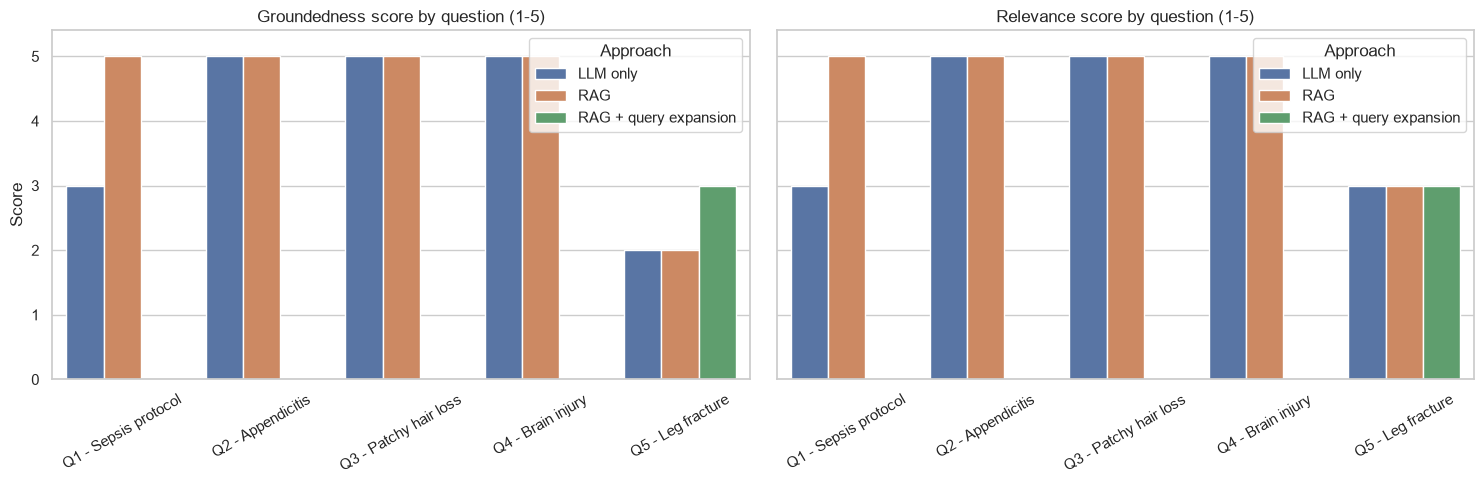

Mean scores by approach


,groundedness,relevance
Approach,,
LLM only,4.0,4.2
RAG,4.4,4.6
RAG + query expansion,3.0,3.0


In [48]:
plot_df = evaluation_df.melt(
    id_vars=["Question", "Approach"], value_vars=["groundedness", "relevance"],
    var_name="Metric", value_name="Score",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, metric in zip(axes, ["groundedness", "relevance"]):
    sns.barplot(data=plot_df[plot_df["Metric"] == metric], x="Question", y="Score",
                hue="Approach", ax=ax)
    ax.set_title(f"{metric.capitalize()} score by question (1-5)")
    ax.set_ylim(0, 5.4)
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("Mean scores by approach")
evaluation_df.groupby("Approach")[["groundedness", "relevance"]].mean().round(2)

In [49]:
# Inspect a judge rationale in full to sanity-check that the scores are reasoned, not arbitrary
row = evaluation_df[(evaluation_df["Question"] == "Q2 - Appendicitis") &
                    (evaluation_df["Approach"] == "RAG")].iloc[0]
print("GROUNDEDNESS\n")
show(row["groundedness_rationale"])
print("\n\nRELEVANCE\n")
show(row["relevance_rationale"])

GROUNDEDNESS

Score: 5

The AI-generated answer follows the metric completely as it is derived solely from the context provided,
detailing the common symptoms of appendicitis and the fact that it cannot be cured via medicine alone, but
rather requires surgical removal. The answer also mentions the standard surgical procedures for treating
appendicitis and a potential complication, as well as the importance of removing a Meckel's diverticulum in
certain cases.


RELEVANCE

Score: 5

The AI-generated answer addresses every main aspect of the question. It correctly lists the common symptoms of
appendicitis and clarifies that it cannot be cured via medicine alone. The answer also explains the standard
treatment for appendicitis, which is surgical removal, and mentions alternative treatments in certain
situations.


**Observations - and the headline finding is how little these metrics discriminate:**

- **RAG wins on the mean, but by far less than the qualitative differences warrant.** Groundedness averages 4.4 for RAG against 4.0 for the ungrounded baseline; relevance 4.6 against 4.2. Read alongside Section 5, where RAG supplied CVP/PAOP endpoints, a dopamine dose threshold, McBurney's point and three named examination signs that the baseline simply did not contain, a 0.4-point gap badly understates the difference. **If this evaluation were the only evidence, the business case for RAG would look marginal.** It is not; the metrics are weak.

- **Only Q1 separates the two approaches at all** (baseline 3/3 versus RAG 5/5). On appendicitis, hair loss and brain injury the judge awarded the ungrounded baseline a **perfect 5 for groundedness** - against context those answers never saw. That is a straightforward metric failure: groundedness is defined as deriving content only from the provided context, and a baseline answer generated with no context at all cannot satisfy it. The judge appears to be rewarding *consistency with* the context rather than *derivation from* it, which is a much weaker property and one that any fluent, medically conventional answer will satisfy.

- **Relevance is nearly uninformative here.** Eight of ten scores are 5, including answers that visibly truncate mid-sentence (appendicitis) and one whose entire rehabilitation limb is the single word "Rehabilitation" (brain injury). The rubric's own instruction - that a partly answered multi-part question "must not score above 3" - was not applied even to the baseline appendicitis answer, which never addressed two of its three limbs.

- **Query 5 is the one place the metrics earn their keep, and it works differently than expected.** Both the baseline and the wrong-chapter RAG answer score 2 on groundedness; query expansion raises it to 3. So the judge *did* catch this failure - but only because the RAG answer openly announced that its context was about snakebites. **The dangerous variant is the one this evaluation would still miss:** an answer faithfully derived from the wrong chapter, which scores well precisely because it is well grounded. Groundedness and relevance measure faithfulness to retrieved text, never clinical correctness or retrieval precision. The chapter-level report from Section 4.6 is a required third metric, not an optional diagnostic.

- **Beware the summary table's third column.** "RAG + query expansion" shows a mean of 3.0/3.0 only because it was run on Q5 alone - the hardest question. Comparing it to the other columns' five-question means would make the best configuration look like the worst. Aggregate metrics over unequal question sets are actively misleading.

- **The judge is the model marking its own work**, and the results show the predicted leniency: 5 is awarded in 14 of 22 scores, and the two lowest-scoring answers are the ones that explicitly confessed their own limitations. Self-evaluation here rewards *stated confidence calibration* more than substance. These scores are usable as a coarse relative signal between configurations of the same pipeline; they cannot support absolute quality claims, and any clinical pilot needs a stronger external judge plus clinician review against a labelled set.

---
## 8. Actionable Insights and Business Recommendations

### 8.1 What the Prototype Demonstrates

A retrieval-augmented assistant built on the Merck Manual with an open-weight quantised 7B model, running on a single consumer GPU, answers real clinical questions with **source-traceable, manual-specific detail** that the same model cannot produce unaided. Concretely:

| | Ungrounded LLM | Prompt-engineered LLM | RAG (k=3) |
| --- | --- | --- | --- |
| Clinical specificity | Plausible prose; correct on common topics, quietly miscategorised on detail | Well structured and ordered, still unsourced | Manual-level detail: CVP/PAOP endpoints, dopamine dose threshold, McBurney's point, Rovsing/obturator/psoas signs |
| Verifiability | None | None | Traceable to chapter and page |
| Multi-part coverage | Poor - 2 of 5 answers never reached later limbs | Good; structure enforced every limb | Good where retrieval hit the right chapter (4 of 5) |
| Truncation at default budget | All 5 answers | 2 of 5 (fixed by verbosity caps) | 3 of 5 at 350 tokens |
| Mean groundedness (judged) | 4.0 | not scored | 4.4 |
| Main failure mode | Plausible but unverifiable; invented specifics under format pressure | Same, and formatting makes it look more authoritative | Confident answer whose provenance silently reverts to pre-training |

**A caveat on that groundedness row:** the 4.0-versus-4.4 gap is far narrower than the qualitative gap, because the LLM-as-a-judge evaluation awarded the ungrounded baseline perfect groundedness scores on three of five questions (Section 7). The business case for RAG rests on the *content* comparison in row one, which is directly inspectable, not on the judged scores.

The business implication is that the bottleneck shifts. With a bare LLM the constraint is *knowledge*; with RAG the constraint is *retrieval quality*. That is a far better problem to have, because retrieval is observable, measurable and fixable without retraining anything.

### 8.2 Key Findings

1. **Grounding, not model size, drives clinical usefulness.** A quantised 7B model with the right three chunks outperforms the same model answering from memory, on every question where retrieval worked. Investment should go into the retrieval layer before it goes into larger models.

2. **The dangerous failure is a silent change of provenance.** For the leg-fracture question the retriever returned snakebite and falls passages. The hardened prompt did stop the model presenting snakebite management as fracture care - a real gain - but it then answered from pre-training instead of abstaining, while still presenting as a manual-backed assistant. **Any clinical deployment must surface its sources on every answer**, because a source list is the only signal a user gets that the system has quietly stopped using the manual.

3. **The root cause was vocabulary, not tuning.** A general-purpose embedding model mapped "hiking trip" nearer to wilderness first aid than to fractures. Rewriting the query into clinical terminology retrieved all three chunks from the fractures chapter at `k=3` - something neither `k=8` nor MMR achieved.

4. **The tuning levers are non-monotonic, so tune against retrieval diagnostics rather than fluency.** Halving the chunk size cut cost 41% but *broke* MMR retrieval on the failing query; `k=2` matched `k=3` on one question while `k=6` was necessary on another. Every configuration produced a fluent answer, including one that advised consulting a zoo about a hiking fracture. Answer quality is not a usable tuning signal; chapter-level provenance is.

5. **Prompt engineering and RAG solve different problems and are complementary.** Structure instructions guarantee that every limb of a multi-part question is answered; retrieval guarantees the content is real. Neither substitutes for the other, and the strongest answers used both. Note also that structure alone can *increase* risk: mandating five bullets per section produced an invented "low-fiber diet" recommendation for appendicitis.

6. **Self-evaluation is too lenient to serve as a quality gate.** The judge is the model under test. It awarded the ungrounded baseline perfect groundedness on three of five questions, and 5s account for 14 of 22 scores overall. The two lowest scores went to the answers that openly admitted their own limitations, so the metric partly rewards self-deprecation. Retrieval precision must be measured separately from answer faithfulness, against a labelled set and an external judge.

7. **Index-build correctness is a first-order concern, not plumbing.** Because Chroma appends to an existing persisted collection rather than replacing it, rebuilding the index without clearing it first double-indexes the corpus - 9,314 vectors for 4,657 chunks. Retrieval keeps working and answers keep reading fluently, but `k=3` delivers as few as two distinct passages and `k=2` just one, quietly halving retrieval breadth. The only visible symptom is a repeated chapter and page in the retrieval report. **Any production index needs an assertion that vector count matches chunk count**, plus a duplicate check; silent index corruption is indistinguishable from mediocre retrieval when judged on output alone.

### 8.3 Recommendations

**Immediate (days, no infrastructure change)**
1. **Show sources on every answer** - chapter and page, alongside the text. This is the single highest-value change: it converts an unverifiable assistant into an auditable reference tool and mitigates finding 2 directly.
2. **Deploy clinical query expansion, with a constrained output format.** One extra ~60-token call per question moved the notebook's worst failure from 2/3 to 3/3 and is the cheapest available quality win. Constrain it: the rewrite in Section 6.3 returned two alternative queries and a stray quotation mark, and a hand-written clinical query still outperformed it, so enforce a single-line schema and validate before retrieving.
3. **Switch the default search type to MMR on the 1000/100 index, and keep `k` at 4-6 for multi-part questions.** Pure similarity search over a heterogeneous 4,000-page manual returns redundant clusters. Validate this pairing before changing chunk size: MMR surfaced the fractures chapter on the 1000/100 index and failed to on the 500/50 index.
4. **Assert index integrity in the build pipeline** - vector count equals chunk count, plus a duplicate-content check. This notebook silently ran on a double-indexed store until provenance printing exposed it.
5. **Keep decoding near-greedy (`temperature` ≤ 0.2)** and enforce the abstention rule and the safety disclaimer in the system prompt - while treating prompt rules as probabilistic. Query 5 showed the model acknowledging off-topic context and then answering anyway instead of returning the abstention string.
6. **Add a retrieval-score threshold before generation.** If the best chunk's similarity falls below a calibrated floor, abstain outside the model rather than asking it to police itself. This is the deterministic guarantee the prompt cannot give.

**Near term (weeks)**
7. **Evaluate a biomedical embedding model** (for example BioBERT- or PubMedBERT-based, or a medical-tuned BGE variant) against the general-purpose one. Finding 3 says this is where the residual retrieval errors live.
8. **Add a cross-encoder re-ranker** over a wider candidate pool: retrieve 20, re-rank, keep 4. This raises precision without paying the context cost of a large `k`, and it directly addresses two observed problems - the fractures chapter arriving only at rank 8, and a chapter introduction outranking the specific protocol on the sepsis query.
9. **Add hybrid retrieval (BM25 + dense).** Exact clinical strings - drug names, scores, chapter titles - are exactly what lexical search handles best and dense retrieval handles worst. A lexical match on "fracture" would have rescued Query 5 outright.
10. **Build a labelled evaluation set** of 50-100 clinician-written question/answer/expected-chapter triples, and track *retrieval precision@k* alongside groundedness and relevance. Section 7 showed the current metrics awarding perfect groundedness to ungrounded answers, so they cannot be the gate.

**Strategic (quarters)**
11. **Human-in-the-loop by design.** Position the tool as decision *support* with mandatory clinician review, capture thumbs-up/down plus the retrieved sources, and use that feedback both to fine-tune retrieval and to build the regulatory audit trail.
12. **Expand the corpus** beyond a single manual - formularies, local protocols, guideline updates - with per-document versioning, so answers can cite which edition they came from. This also addresses a currency gap the notebook surfaced from the other direction: the model volunteered JAK inhibitors for alopecia areata, a therapy the 19th-edition manual predates.
13. **Extract figures and tables explicitly.** Text extraction covered all 4,114 pages, so there is no page-level blind spot, but diagrams and dosage tables embedded within otherwise-readable pages are still unretrievable, and clinical manuals put decision-critical content in tables. Scope this from a sample audit rather than assuming the gap's size.
14. **Plan for governance:** response-latency and cost budgets, PHI handling if patient context is ever added, and periodic revalidation whenever the manual, the embedding model or the LLM is updated.

### 8.4 Expected Business Impact

- **Time saved per query:** minutes of manual searching reduced to seconds, with the source page cited for verification - the direct answer to the information-overload problem in the business context.
- **Standardisation of care:** every clinician is answered from the same authoritative text, reducing variation driven by individual recall.
- **Cost profile:** an open-weight quantised model on a single GPU avoids per-token API costs and keeps the manual and any future patient context inside the organisation's own infrastructure.
- **Adoption risk:** entirely concentrated in retrieval quality and source transparency. The recommendations above are ordered accordingly.

---

### Conclusion

The prototype answers the project's core question affirmatively: a RAG pipeline over the Merck Manual turns a general-purpose 7B model into a genuinely useful, source-traceable clinical reference, on hardware a single department could afford. On four of five questions it produced manual-specific detail - resuscitation endpoints, dose thresholds, named examination signs - that the same model could not produce unaided.

It also identifies precisely where the remaining risk sits, and it is not in the language model. It is in the retriever's ability to bridge the language clinicians and patients actually use to the language the manual is written in, and in the fact that **every failure mode encountered was invisible in the output**: a wrong-chapter answer read as fluently as a right one, a double-indexed store degraded retrieval without raising an error, and the automated judge rated ungrounded answers as perfectly grounded. Query expansion, MMR retrieval, index-integrity assertions and mandatory source display address these today. A biomedical embedding model, a cross-encoder re-ranker, a retrieval-score abstention threshold and a labelled retrieval benchmark with clinician review are the prerequisites for any clinical pilot.

<font size=6 color='blue'>Power Ahead</font>

___